# 🌍 Air Quality Analysis — 16 Selected Stations
**Mục tiêu:** Load, merge và phân tích dữ liệu không khí + thời tiết cho 16 trạm đã chọn.

| Trạm | Tỉnh/TP | Quận/Huyện |
|------|---------|------------|
| 1 | Hà Nội | Cầu Giấy |
| 3 | Hà Nội | Tây Hồ |
| 4 | Hà Nội | Yên Lãng |
| 7 | TP.HCM | Quận 1 |
| 9 | TP.HCM | Bình Thạnh |
| 12 | TP.HCM | Bình Chánh |
| 13 | Đà Nẵng | Thanh Khê |
| 15 | Đà Nẵng | Liên Chiểu |
| 16 | Hải Phòng | Đồ Sơn |
| 17 | Hải Phòng | Hồng Bàng |
| 18 | Cần Thơ | Ninh Kiều |
| 24 | Đồng Nai | Biên Hòa |
| 27 | Nam Định | Nam Định |
| 29 | Nghệ An | Nghệ An |
| 31 | Trà Vinh | Trà Vinh |
| 32 | An Giang | Rạch Giá |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('tab10')

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load & Merge Data

In [3]:
# ─── Cấu hình ────────────────────────────────────────────────────────────────
SELECTED_STATIONS = [1, 3, 4, 7, 9, 12, 13, 15, 16, 17, 18, 24, 27, 29, 31, 32]

AIR_DIR     = 'data/raw/air'
WEATHER_DIR = 'data/raw/weather'
INFO_PATH   = 'data/info.csv'

# ─── Cột cần lấy ─────────────────────────────────────────────────────────────
AIR_COLS = {
    'pm25' : 'PM2.5',
    'pm10' : 'PM10',
    'co'   : 'CO',
    'o3'   : 'O3',
    'no2'  : 'NO2',
    'so2'  : 'SO2',
    'aqi'  : 'AQI',
}

WEATHER_COLS = {
    'temperature_2m (°C)'       : 'Temperature',
    'relative_humidity_2m (%)'  : 'Humidity',
    'precipitation (mm)'        : 'Precipitation',
    'cloud_cover (%)'           : 'Cloud_Cover',
    'wind_speed_10m (m/s)'      : 'Wind_Speed',
    'wind_direction_10m (°)'    : 'Wind_Dir',
}

print('✅ Config done')
print(f'   → {len(SELECTED_STATIONS)} trạm được chọn: {SELECTED_STATIONS}')

✅ Config done
   → 16 trạm được chọn: [1, 3, 4, 7, 9, 12, 13, 15, 16, 17, 18, 24, 27, 29, 31, 32]


In [4]:
# ─── Load station metadata ────────────────────────────────────────────────────
info_df = pd.read_csv(INFO_PATH)
info_df = info_df[info_df['station'].isin(SELECTED_STATIONS)].set_index('station')
print('Station info:')
display(info_df)

Station info:


,province,district,latitude,longitude
station,,,,
1,Ha Noi,Cau Giay,21.0323,105.80070
3,Ha Noi,Tay Ho,21.0690,105.81050
4,Ha Noi,Yen Lang,19.9500,105.50000
7,TP.HCM,Quan 1,10.7807,106.69940
9,TP.HCM,Quan Binh Thanh,10.8033,106.69670
12,TP.HCM,Huyen Binh Chanh,10.6954,106.59130
13,Da Nang,Thanh Khe,16.0706,108.19100
15,Da Nang,Lien Chieu,16.0177,108.20380
16,Hai Phong,Do Son,20.7136,106.78940


In [6]:
def load_air(station_id: int) -> pd.DataFrame:
    """Load và chuẩn hóa air quality data cho một trạm."""
    df = pd.read_csv(f'{AIR_DIR}/air_{station_id}.csv')
    
    # Parse datetime
    df['datetime'] = pd.to_datetime(df['timestamp_local'])
    df = df.set_index('datetime').sort_index()
    
    # Chỉ giữ cột cần thiết & đổi tên
    cols_available = {k: v for k, v in AIR_COLS.items() if k in df.columns}
    df = df[list(cols_available.keys())].rename(columns=cols_available)
    
    # Ép về numeric
    df = df.apply(pd.to_numeric, errors='coerce')
    return df


def load_weather(station_id: int) -> pd.DataFrame:
    """Load và chuẩn hóa weather data cho một trạm."""
    df = pd.read_csv(f'{WEATHER_DIR}/weather_{station_id}.csv')
    
    # Parse datetime
    df['datetime'] = pd.to_datetime(df['time'])
    df = df.set_index('datetime').sort_index()
    
    # Chỉ giữ cột cần thiết & đổi tên
    cols_available = {k: v for k, v in WEATHER_COLS.items() if k in df.columns}
    df = df[list(cols_available.keys())].rename(columns=cols_available)
    
    df = df.apply(pd.to_numeric, errors='coerce')
    return df


print('✅ Functions defined')

✅ Functions defined


In [7]:
# ─── Main loop: load, merge, lưu vào list ─────────────────────────────────────
station_dfs  = []   # list[pd.DataFrame] — mỗi phần tử là 1 trạm
station_meta = []   # list[dict]         — metadata tương ứng

FEATURE_COLS = list(AIR_COLS.values()) + list(WEATHER_COLS.values())

for sid in SELECTED_STATIONS:
    try:
        air_df     = load_air(sid)
        weather_df = load_weather(sid)
        
        # Resample air về hourly (phòng khi có duplicate)
        air_df = air_df.resample('h').mean()
        
        # Merge theo thời gian (inner join → chỉ giữ timestamp có cả 2)
        merged = pd.merge(
            air_df, weather_df,
            left_index=True, right_index=True,
            how='inner'
        )
        
        # Thêm cột định danh trạm
        merged['station_id'] = sid
        merged['province']   = info_df.loc[sid, 'province']
        merged['district']   = info_df.loc[sid, 'district']
        
        station_dfs.append(merged)
        station_meta.append({
            'station_id' : sid,
            'province'   : info_df.loc[sid, 'province'],
            'district'   : info_df.loc[sid, 'district'],
            'n_rows'     : len(merged),
            'start'      : merged.index.min(),
            'end'        : merged.index.max(),
            'missing_pct': round(merged[FEATURE_COLS].isnull().mean().mean() * 100, 2),
        })
        print(f'  ✅ Trạm {sid:2d} | {info_df.loc[sid,"province"]:12s} - {info_df.loc[sid,"district"]:15s} | '
              f'{len(merged):,} rows | missing {station_meta[-1]["missing_pct"]}%')
        
    except Exception as e:
        print(f'  ❌ Trạm {sid}: {e}')

print(f'\n🎯 Đã load xong {len(station_dfs)}/{len(SELECTED_STATIONS)} trạm')

  ✅ Trạm  1 | Ha Noi       - Cau Giay        | 25,561 rows | missing 0.0%
  ✅ Trạm  3 | Ha Noi       - Tay Ho          | 25,561 rows | missing 0.0%
  ✅ Trạm  4 | Ha Noi       - Yen Lang        | 25,561 rows | missing 0.0%
  ✅ Trạm  7 | TP.HCM       - Quan 1          | 25,561 rows | missing 0.0%
  ✅ Trạm  9 | TP.HCM       - Quan Binh Thanh | 25,561 rows | missing 0.0%
  ✅ Trạm 12 | TP.HCM       - Huyen Binh Chanh | 25,561 rows | missing 0.0%
  ✅ Trạm 13 | Da Nang      - Thanh Khe       | 25,561 rows | missing 0.0%
  ✅ Trạm 15 | Da Nang      - Lien Chieu      | 25,561 rows | missing 0.0%
  ✅ Trạm 16 | Hai Phong    - Do Son          | 25,561 rows | missing 0.0%
  ✅ Trạm 17 | Hai Phong    - Hong Bang       | 25,561 rows | missing 0.0%
  ✅ Trạm 18 | Can Tho      - Ninh Kieu       | 25,561 rows | missing 0.0%
  ✅ Trạm 24 | Dong Nai     - Bien Hoa        | 25,561 rows | missing 0.0%
  ✅ Trạm 27 | Nam Dinh     - Nam Dinh        | 25,561 rows | missing 0.0%
  ✅ Trạm 29 | Nghe An      - Nghe An 

In [8]:
# ─── Tổng quan chất lượng dữ liệu ────────────────────────────────────────────
meta_df = pd.DataFrame(station_meta)
print('📋 Tổng quan 16 trạm:')
display(meta_df.to_string(index=False))

📋 Tổng quan 16 trạm:


' station_id  province         district  n_rows      start        end  missing_pct\n          1    Ha Noi         Cau Giay   25561 2023-01-01 2025-12-01          0.0\n          3    Ha Noi           Tay Ho   25561 2023-01-01 2025-12-01          0.0\n          4    Ha Noi         Yen Lang   25561 2023-01-01 2025-12-01          0.0\n          7    TP.HCM           Quan 1   25561 2023-01-01 2025-12-01          0.0\n          9    TP.HCM  Quan Binh Thanh   25561 2023-01-01 2025-12-01          0.0\n         12    TP.HCM Huyen Binh Chanh   25561 2023-01-01 2025-12-01          0.0\n         13   Da Nang        Thanh Khe   25561 2023-01-01 2025-12-01          0.0\n         15   Da Nang       Lien Chieu   25561 2023-01-01 2025-12-01          0.0\n         16 Hai Phong           Do Son   25561 2023-01-01 2025-12-01          0.0\n         17 Hai Phong        Hong Bang   25561 2023-01-01 2025-12-01          0.0\n         18   Can Tho        Ninh Kieu   25561 2023-01-01 2025-12-01          0.0\n   

## 2. Quick Access Helper
Dùng `get_station(id)` để lấy DataFrame của một trạm bất kỳ.

In [9]:
# Helper: lấy df theo station_id thay vì index trong list
_sid_to_idx = {meta['station_id']: i for i, meta in enumerate(station_meta)}

def get_station(station_id: int) -> pd.DataFrame:
    """Trả về DataFrame của trạm theo station_id."""
    idx = _sid_to_idx.get(station_id)
    if idx is None:
        raise ValueError(f'station_id {station_id} không có trong danh sách đã chọn')
    return station_dfs[idx]

# Ví dụ
print('🔍 Ví dụ — Trạm 1 (Cầu Giấy):')
display(get_station(1).head(3))
print(f'   Shape: {get_station(1).shape}')
print(f'   Columns: {list(get_station(1).columns)}')

🔍 Ví dụ — Trạm 1 (Cầu Giấy):


,PM2.5,PM10,CO,O3,NO2,SO2,AQI,Temperature,Humidity,Precipitation,Cloud_Cover,Wind_Speed,Wind_Dir,station_id,province,district
datetime,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,59.0,73.8,224.5,55.7,9.0,62.3,155.0,11.1,80,0.0,0,2.61,356,1,Ha Noi,Cau Giay
2023-01-01 01:00:00,71.0,88.8,206.0,56.0,6.0,59.0,171.0,10.6,83,0.0,2,2.60,344,1,Ha Noi,Cau Giay
2023-01-01 02:00:00,77.0,96.3,203.7,54.0,6.0,58.0,179.0,10.3,85,0.0,6,2.60,344,1,Ha Noi,Cau Giay


   Shape: (25561, 16)
   Columns: ['PM2.5', 'PM10', 'CO', 'O3', 'NO2', 'SO2', 'AQI', 'Temperature', 'Humidity', 'Precipitation', 'Cloud_Cover', 'Wind_Speed', 'Wind_Dir', 'station_id', 'province', 'district']


---
## 3. Visualizations
### 3.1 PM2.5 Time Series — Tất cả 16 trạm

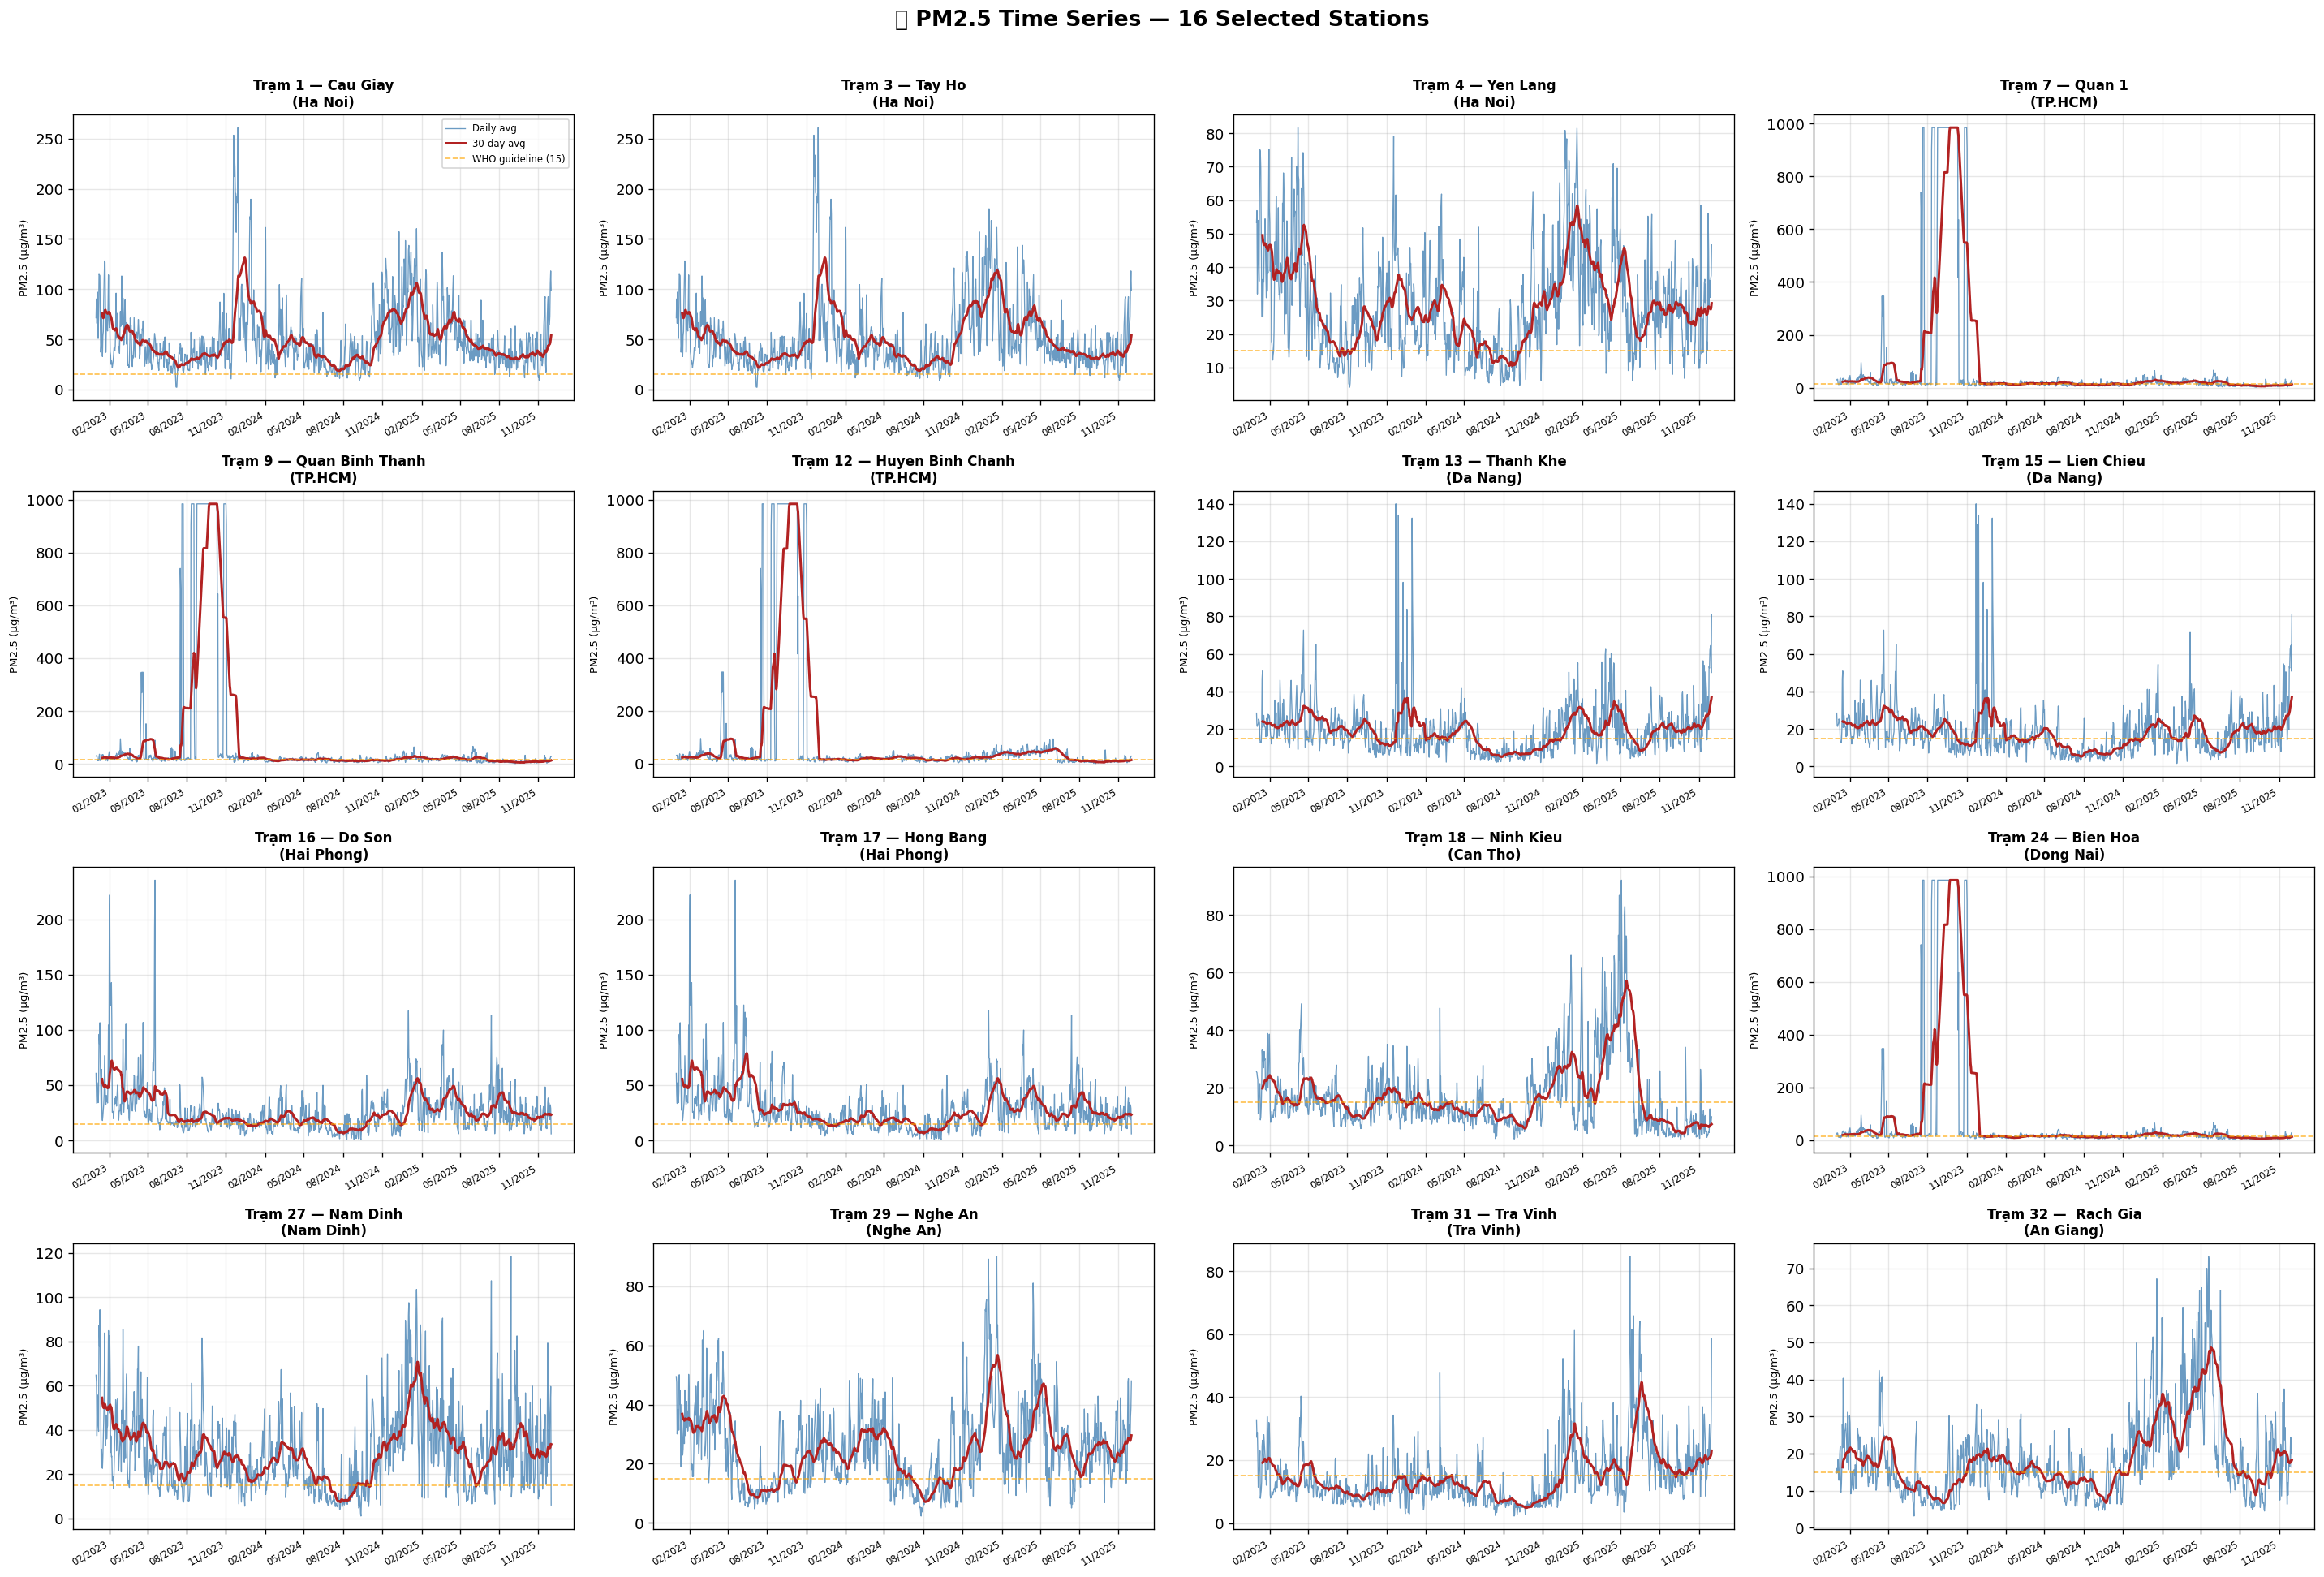

✅ Saved: pm25_timeseries_16stations.png


In [10]:
fig, axes = plt.subplots(4, 4, figsize=(24, 16), sharex=False)
axes = axes.flatten()

for i, (df, meta) in enumerate(zip(station_dfs, station_meta)):
    ax = axes[i]
    daily = df['PM2.5'].resample('D').mean()
    ax.plot(daily, color='steelblue', lw=0.8, alpha=0.8, label='Daily avg')
    
    # Rolling 30-day
    roll = daily.rolling(30, min_periods=15).mean()
    ax.plot(roll, color='firebrick', lw=1.8, label='30-day avg')
    
    # WHO guideline PM2.5 = 15 µg/m³
    ax.axhline(15, color='orange', lw=1, ls='--', alpha=0.7, label='WHO guideline (15)')
    
    ax.set_title(f"Trạm {meta['station_id']} — {meta['district']}\n({meta['province']})",
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

fig.suptitle('📊 PM2.5 Time Series — 16 Selected Stations', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pm25_timeseries_16stations.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: pm25_timeseries_16stations.png')

### 3.2 Distribution — PM2.5 theo tỉnh thành

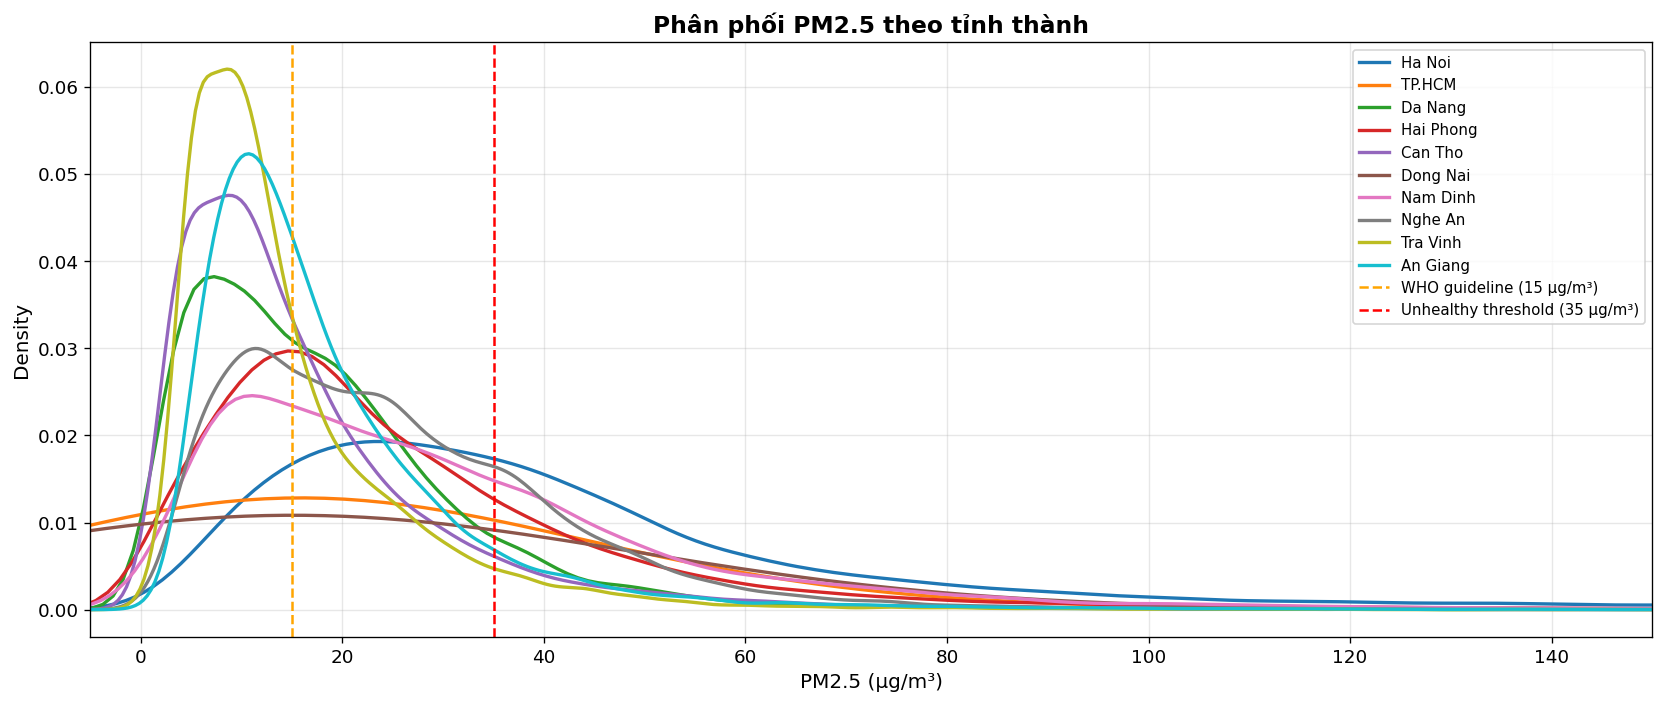

In [11]:
# Gộp tất cả trạm lại để so sánh
all_df = pd.concat(station_dfs)

fig, ax = plt.subplots(figsize=(14, 6))

provinces = all_df['province'].unique()
colors = sns.color_palette('tab10', len(provinces))

for prov, color in zip(provinces, colors):
    vals = all_df[all_df['province'] == prov]['PM2.5'].dropna()
    vals.plot.kde(ax=ax, label=prov, color=color, lw=2)

ax.axvline(15, color='orange', lw=1.5, ls='--', label='WHO guideline (15 µg/m³)')
ax.axvline(35, color='red',    lw=1.5, ls='--', label='Unhealthy threshold (35 µg/m³)')
ax.set_xlabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Phân phối PM2.5 theo tỉnh thành', fontsize=14, fontweight='bold')
ax.set_xlim([-5, 150])
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pm25_distribution_by_province.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.3 Correlation Heatmap — Pollutants + Weather (per station)

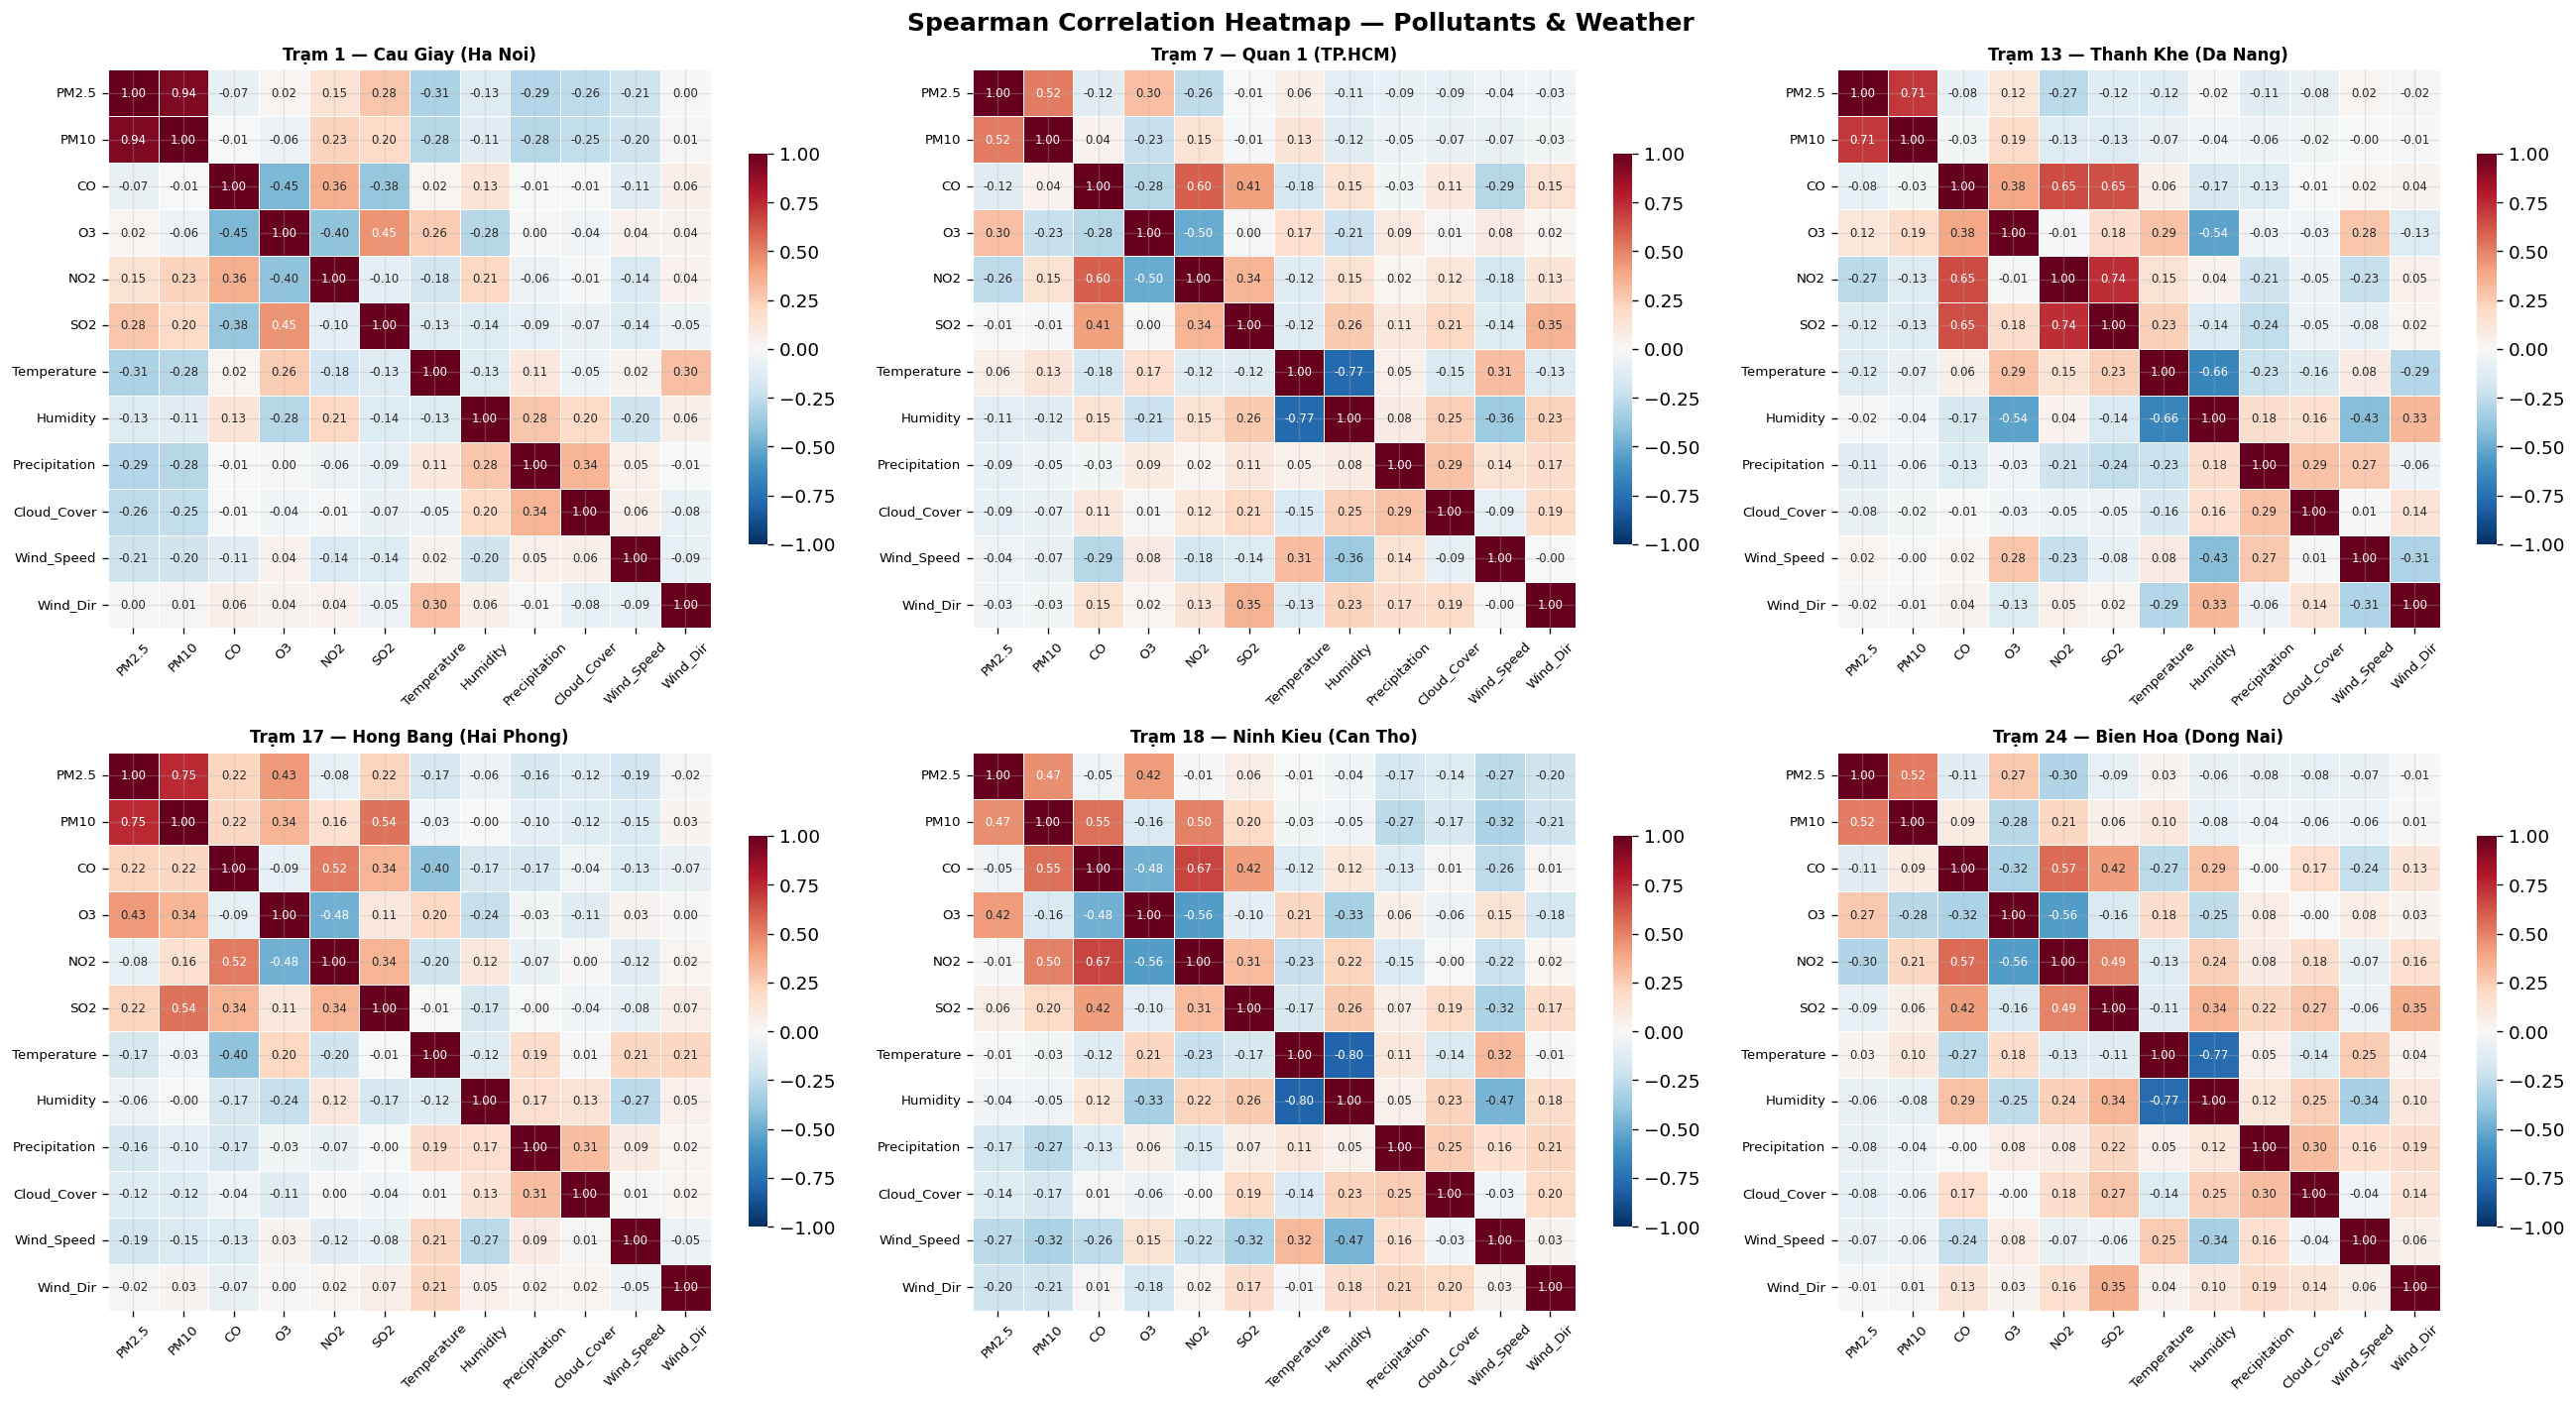

In [12]:
CORR_COLS = ['PM2.5', 'PM10', 'CO', 'O3', 'NO2', 'SO2',
             'Temperature', 'Humidity', 'Precipitation', 'Cloud_Cover',
             'Wind_Speed', 'Wind_Dir']

# Chọn 1 trạm đại diện mỗi vùng để vẽ
sample_stations = [1, 7, 13, 17, 18, 24]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, sid in enumerate(sample_stations):
    df = get_station(sid)
    meta = station_meta[_sid_to_idx[sid]]
    cols_exist = [c for c in CORR_COLS if c in df.columns]
    corr = df[cols_exist].corr(method='spearman')
    
    sns.heatmap(corr, ax=axes[i], annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, annot_kws={'size': 7},
                cbar_kws={'shrink': 0.7})
    axes[i].set_title(f"Trạm {sid} — {meta['district']} ({meta['province']})",
                       fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', rotation=0,  labelsize=8)

fig.suptitle('Spearman Correlation Heatmap — Pollutants & Weather', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.4 Monthly Boxplot PM2.5 — Seasonality

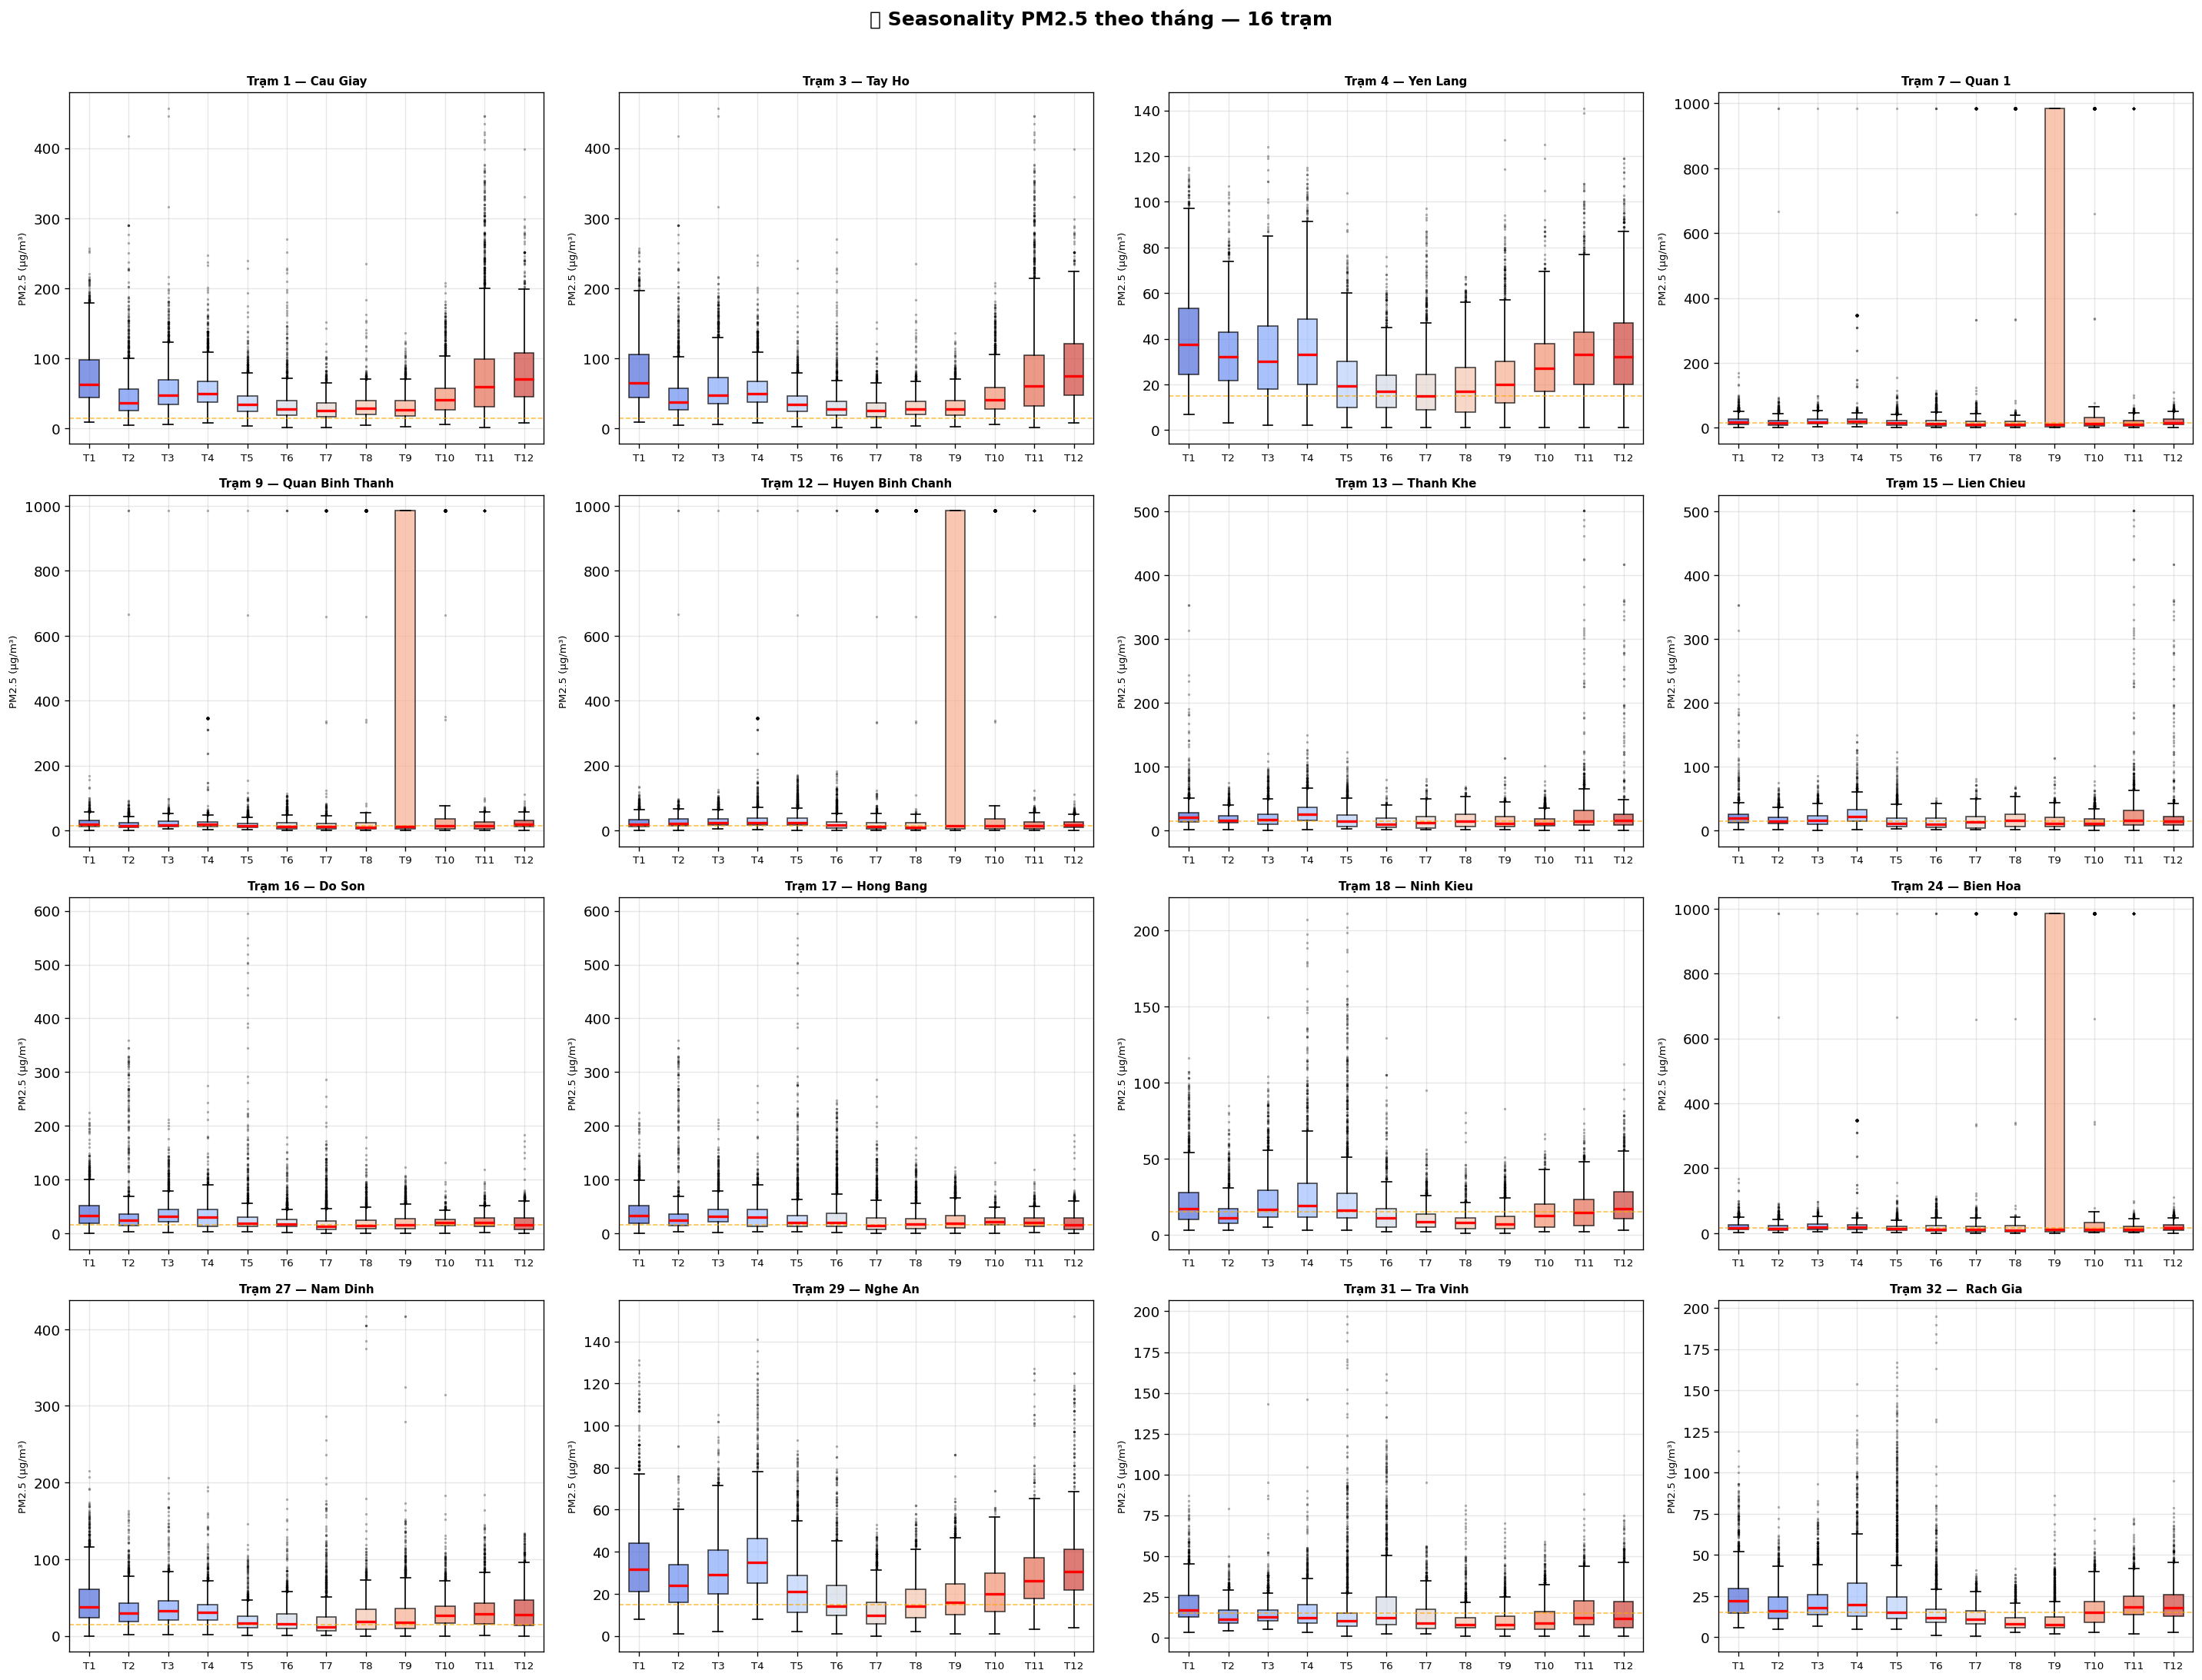

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(24, 18), sharey=False)
axes = axes.flatten()

month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

for i, (df, meta) in enumerate(zip(station_dfs, station_meta)):
    ax = axes[i]
    tmp = df[['PM2.5']].copy()
    tmp['month'] = tmp.index.month
    
    data_by_month = [tmp[tmp['month'] == m]['PM2.5'].dropna().values for m in range(1, 13)]
    bp = ax.boxplot(data_by_month, patch_artist=True, notch=False,
                    medianprops=dict(color='red', lw=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    
    colors_box = sns.color_palette('coolwarm', 12)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.axhline(15, color='orange', lw=1, ls='--', alpha=0.7)
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_title(f"Trạm {meta['station_id']} — {meta['district']}",
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=8)

fig.suptitle('📅 Seasonality PM2.5 theo tháng — 16 trạm', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pm25_monthly_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.5 All Pollutants Overview — Chọn 1 trạm

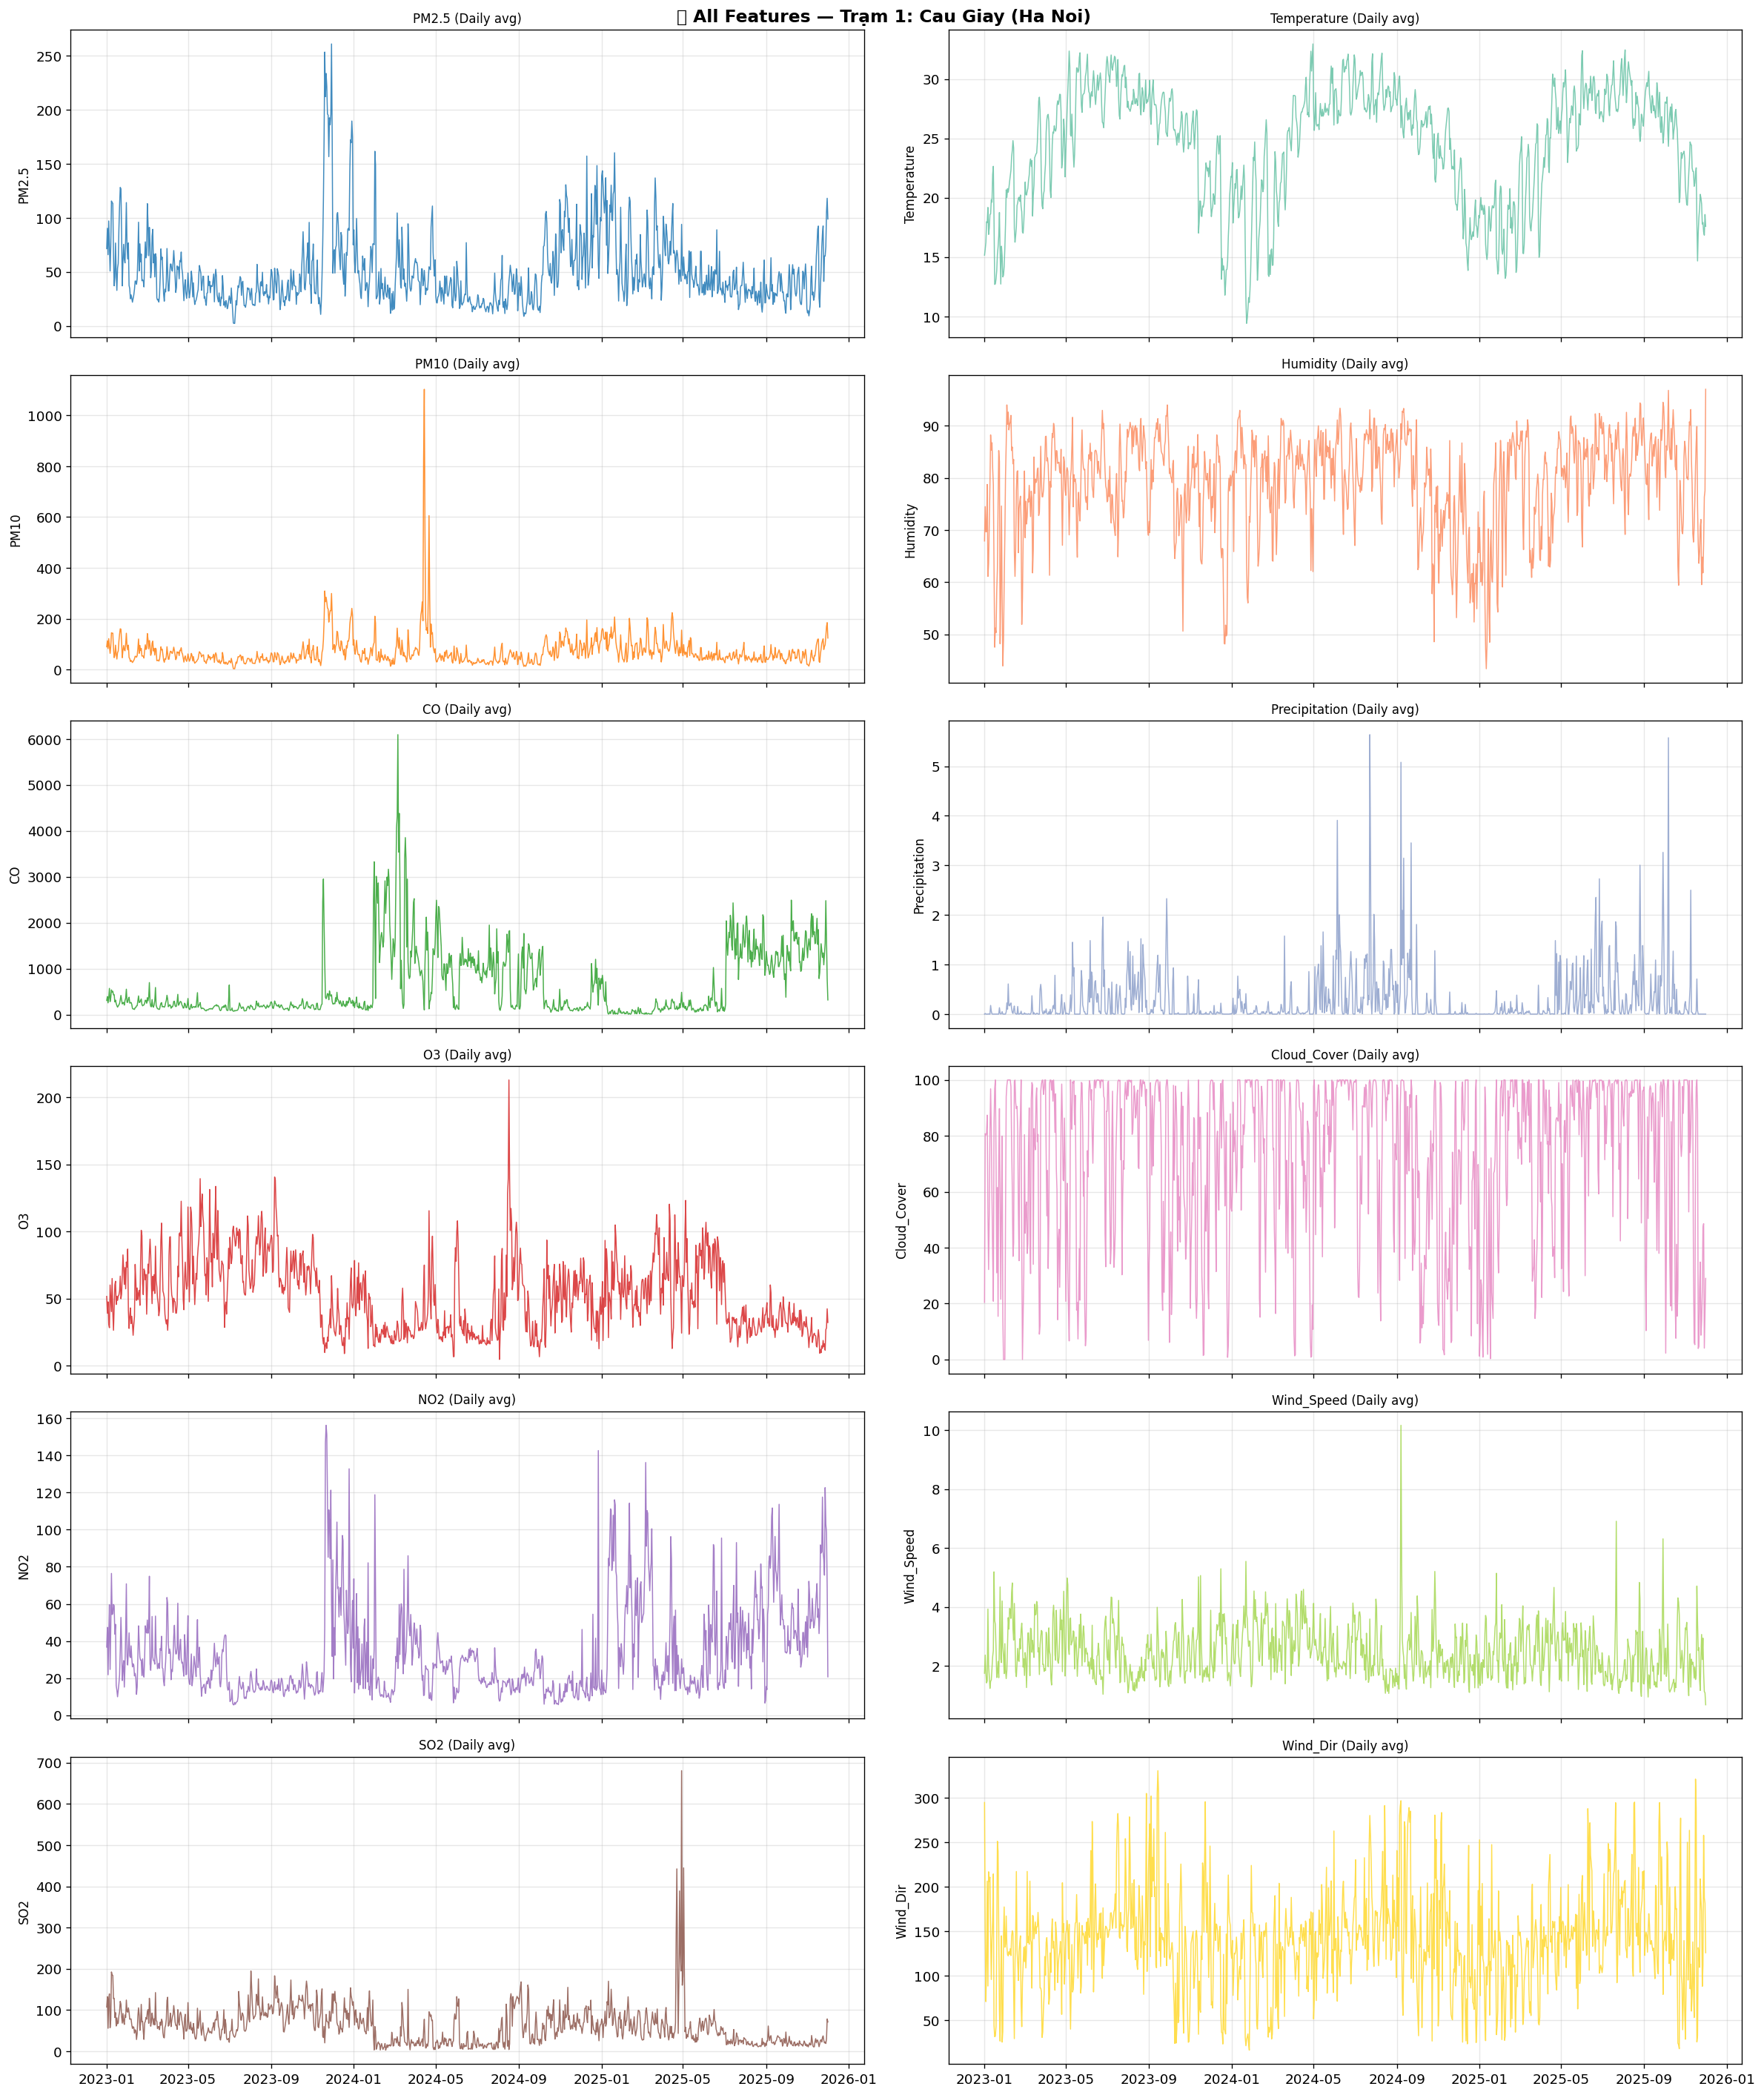

In [17]:
STATION_TO_PLOT = 1   # ← Thay station_id tùy ý

df = get_station(STATION_TO_PLOT)
meta = station_meta[_sid_to_idx[STATION_TO_PLOT]]

pollutants    = ['PM2.5', 'PM10', 'CO', 'O3', 'NO2', 'SO2']
weather_feats = ['Temperature', 'Humidity', 'Precipitation', 'Cloud_Cover', 'Wind_Speed', 'Wind_Dir']

fig, axes = plt.subplots(6, 2, figsize=(20, 24), sharex=True)

# SỬA LỖI Ở DÒNG NÀY: Thêm numeric_only=True
daily = df.resample('D').mean(numeric_only=True)

for i, col in enumerate(pollutants):
    ax = axes[i][0]
    if col in daily.columns:
        ax.plot(daily[col], lw=0.9, color=plt.cm.tab10(i), alpha=0.85)
        ax.set_ylabel(col, fontsize=10)
    ax.set_title(f'{col} (Daily avg)', fontsize=10)

for i, col in enumerate(weather_feats):
    ax = axes[i][1]
    if col in daily.columns:
        ax.plot(daily[col], lw=0.9, color=plt.cm.Set2(i), alpha=0.85)
        ax.set_ylabel(col, fontsize=10)
    ax.set_title(f'{col} (Daily avg)', fontsize=10)

fig.suptitle(
    f"📊 All Features — Trạm {STATION_TO_PLOT}: {meta['district']} ({meta['province']})",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'all_features_station_{STATION_TO_PLOT}.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.6 Missing Data Heatmap — Toàn bộ 16 trạm

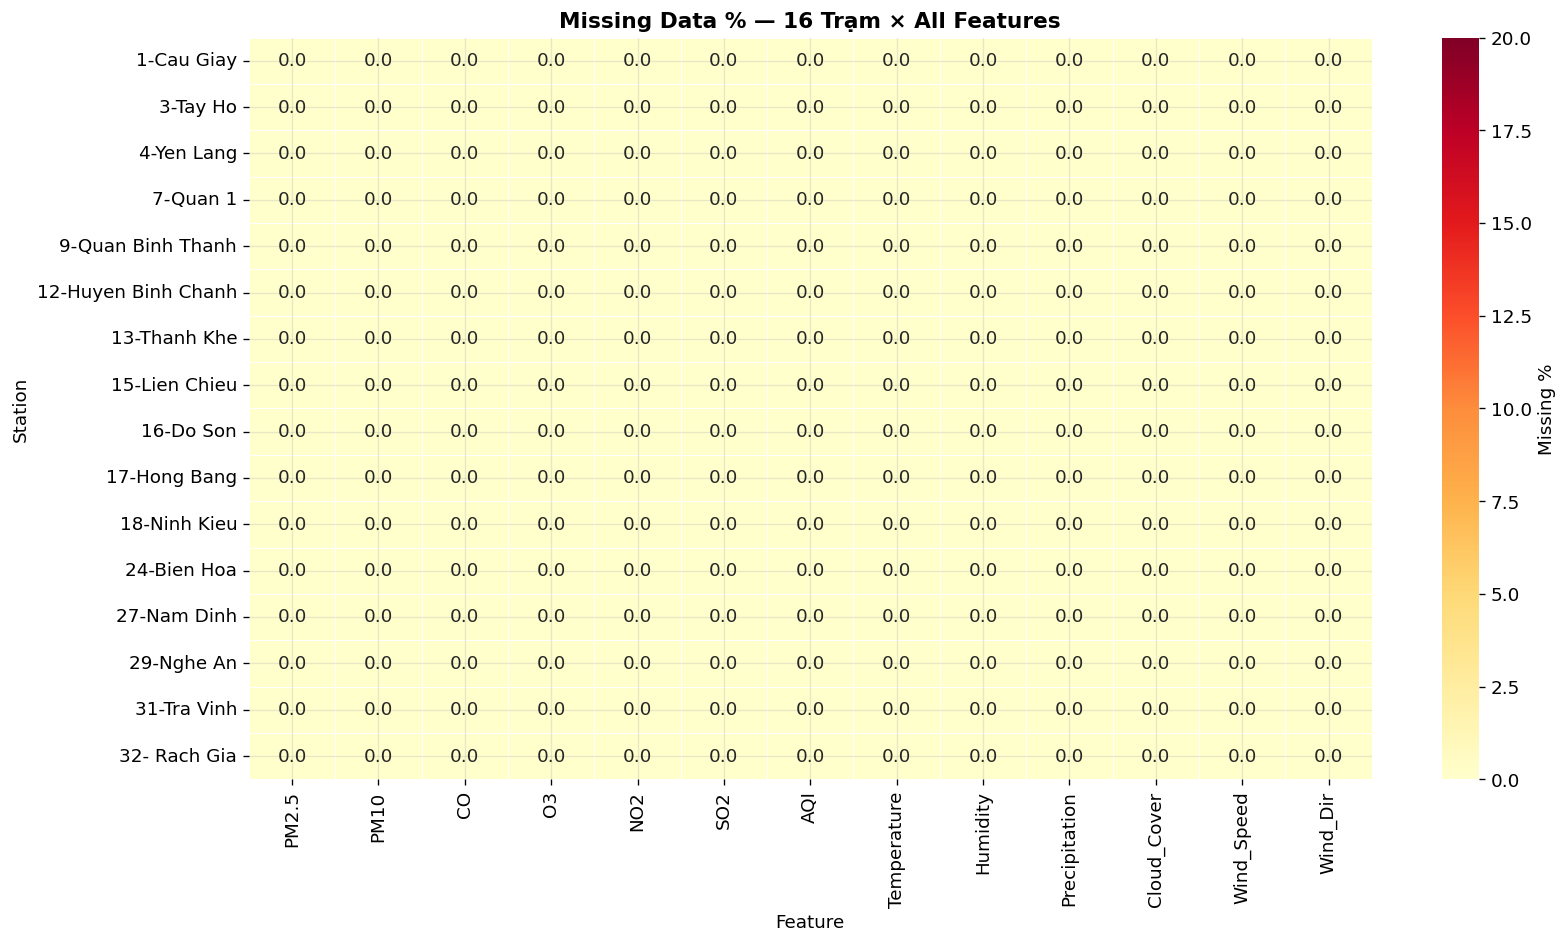

In [16]:
pollutant_cols = ['PM2.5', 'PM10', 'CO', 'O3', 'NO2', 'SO2', 'AQI']
weather_cols_all  = ['Temperature', 'Humidity', 'Precipitation', 'Cloud_Cover', 'Wind_Speed', 'Wind_Dir']
all_feat_cols = pollutant_cols + weather_cols_all

missing_matrix = []
labels = []

for df, meta in zip(station_dfs, station_meta):
    cols_exist = [c for c in all_feat_cols if c in df.columns]
    row = df[cols_exist].isnull().mean() * 100
    # Đảm bảo cùng cột
    row_full = pd.Series({c: row.get(c, np.nan) for c in all_feat_cols})
    missing_matrix.append(row_full)
    labels.append(f"{meta['station_id']}-{meta['district']}")

missing_df = pd.DataFrame(missing_matrix, index=labels, columns=all_feat_cols)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(missing_df, ax=ax, annot=True, fmt='.1f', cmap='YlOrRd',
            vmin=0, vmax=20, linewidths=0.5, cbar_kws={'label': 'Missing %'})
ax.set_title('Missing Data % — 16 Trạm × All Features', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Station', fontsize=11)
plt.tight_layout()
plt.savefig('missing_data_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. 🔍 Deep Dive — TP.HCM & Biên Hòa
**Mục tiêu:** Phân tích cụ thể các bất thường (outliers, phân phối lạ) ở **tháng 9** tại 4 trạm:
- Trạm 7 (Quận 1), Trạm 9 (Bình Thạnh), Trạm 12 (Bình Chánh) — TP.HCM
- Trạm 24 (Biên Hòa) — Đồng Nai

**Khả năng giải thích:**
1. 🔥 Khói xuyên biên giới (đốt rừng Indonesia/Cambodia — thường xảy ra tháng 8-10)
2. 🏭 Nguồn phát thải địa phương tăng đột biến (KCN Biên Hòa, giao thông HCM)
3. ⚠️ Cảm biến lỗi / dữ liệu bất thường cần xử lý

In [18]:
from scipy import stats

# ─── Config ──────────────────────────────────────────────────────────────────
FOCUS_STATIONS = {
    7 : 'Q.1 (HCM)',
    9 : 'Bình Thạnh (HCM)',
    12: 'Bình Chánh (HCM)',
    24: 'Biên Hòa (Đồng Nai)',
}
COLORS = {7: '#E63946', 9: '#F4A261', 12: '#2A9D8F', 24: '#6A0572'}

focus_dfs = {sid: get_station(sid) for sid in FOCUS_STATIONS}
print('✅ Focus stations loaded')
for sid, lbl in FOCUS_STATIONS.items():
    df = focus_dfs[sid]
    print(f'  Trạm {sid} {lbl}: {df.index.min().date()} to {df.index.max().date()}, {len(df):,} rows')

✅ Focus stations loaded
  Trạm 7 Q.1 (HCM): 2023-01-01 to 2025-12-01, 25,561 rows
  Trạm 9 Bình Thạnh (HCM): 2023-01-01 to 2025-12-01, 25,561 rows
  Trạm 12 Bình Chánh (HCM): 2023-01-01 to 2025-12-01, 25,561 rows
  Trạm 24 Biên Hòa (Đồng Nai): 2023-01-01 to 2025-12-01, 25,561 rows


### 4.1 Time Series PM2.5 — Highlight tháng 9 qua các năm

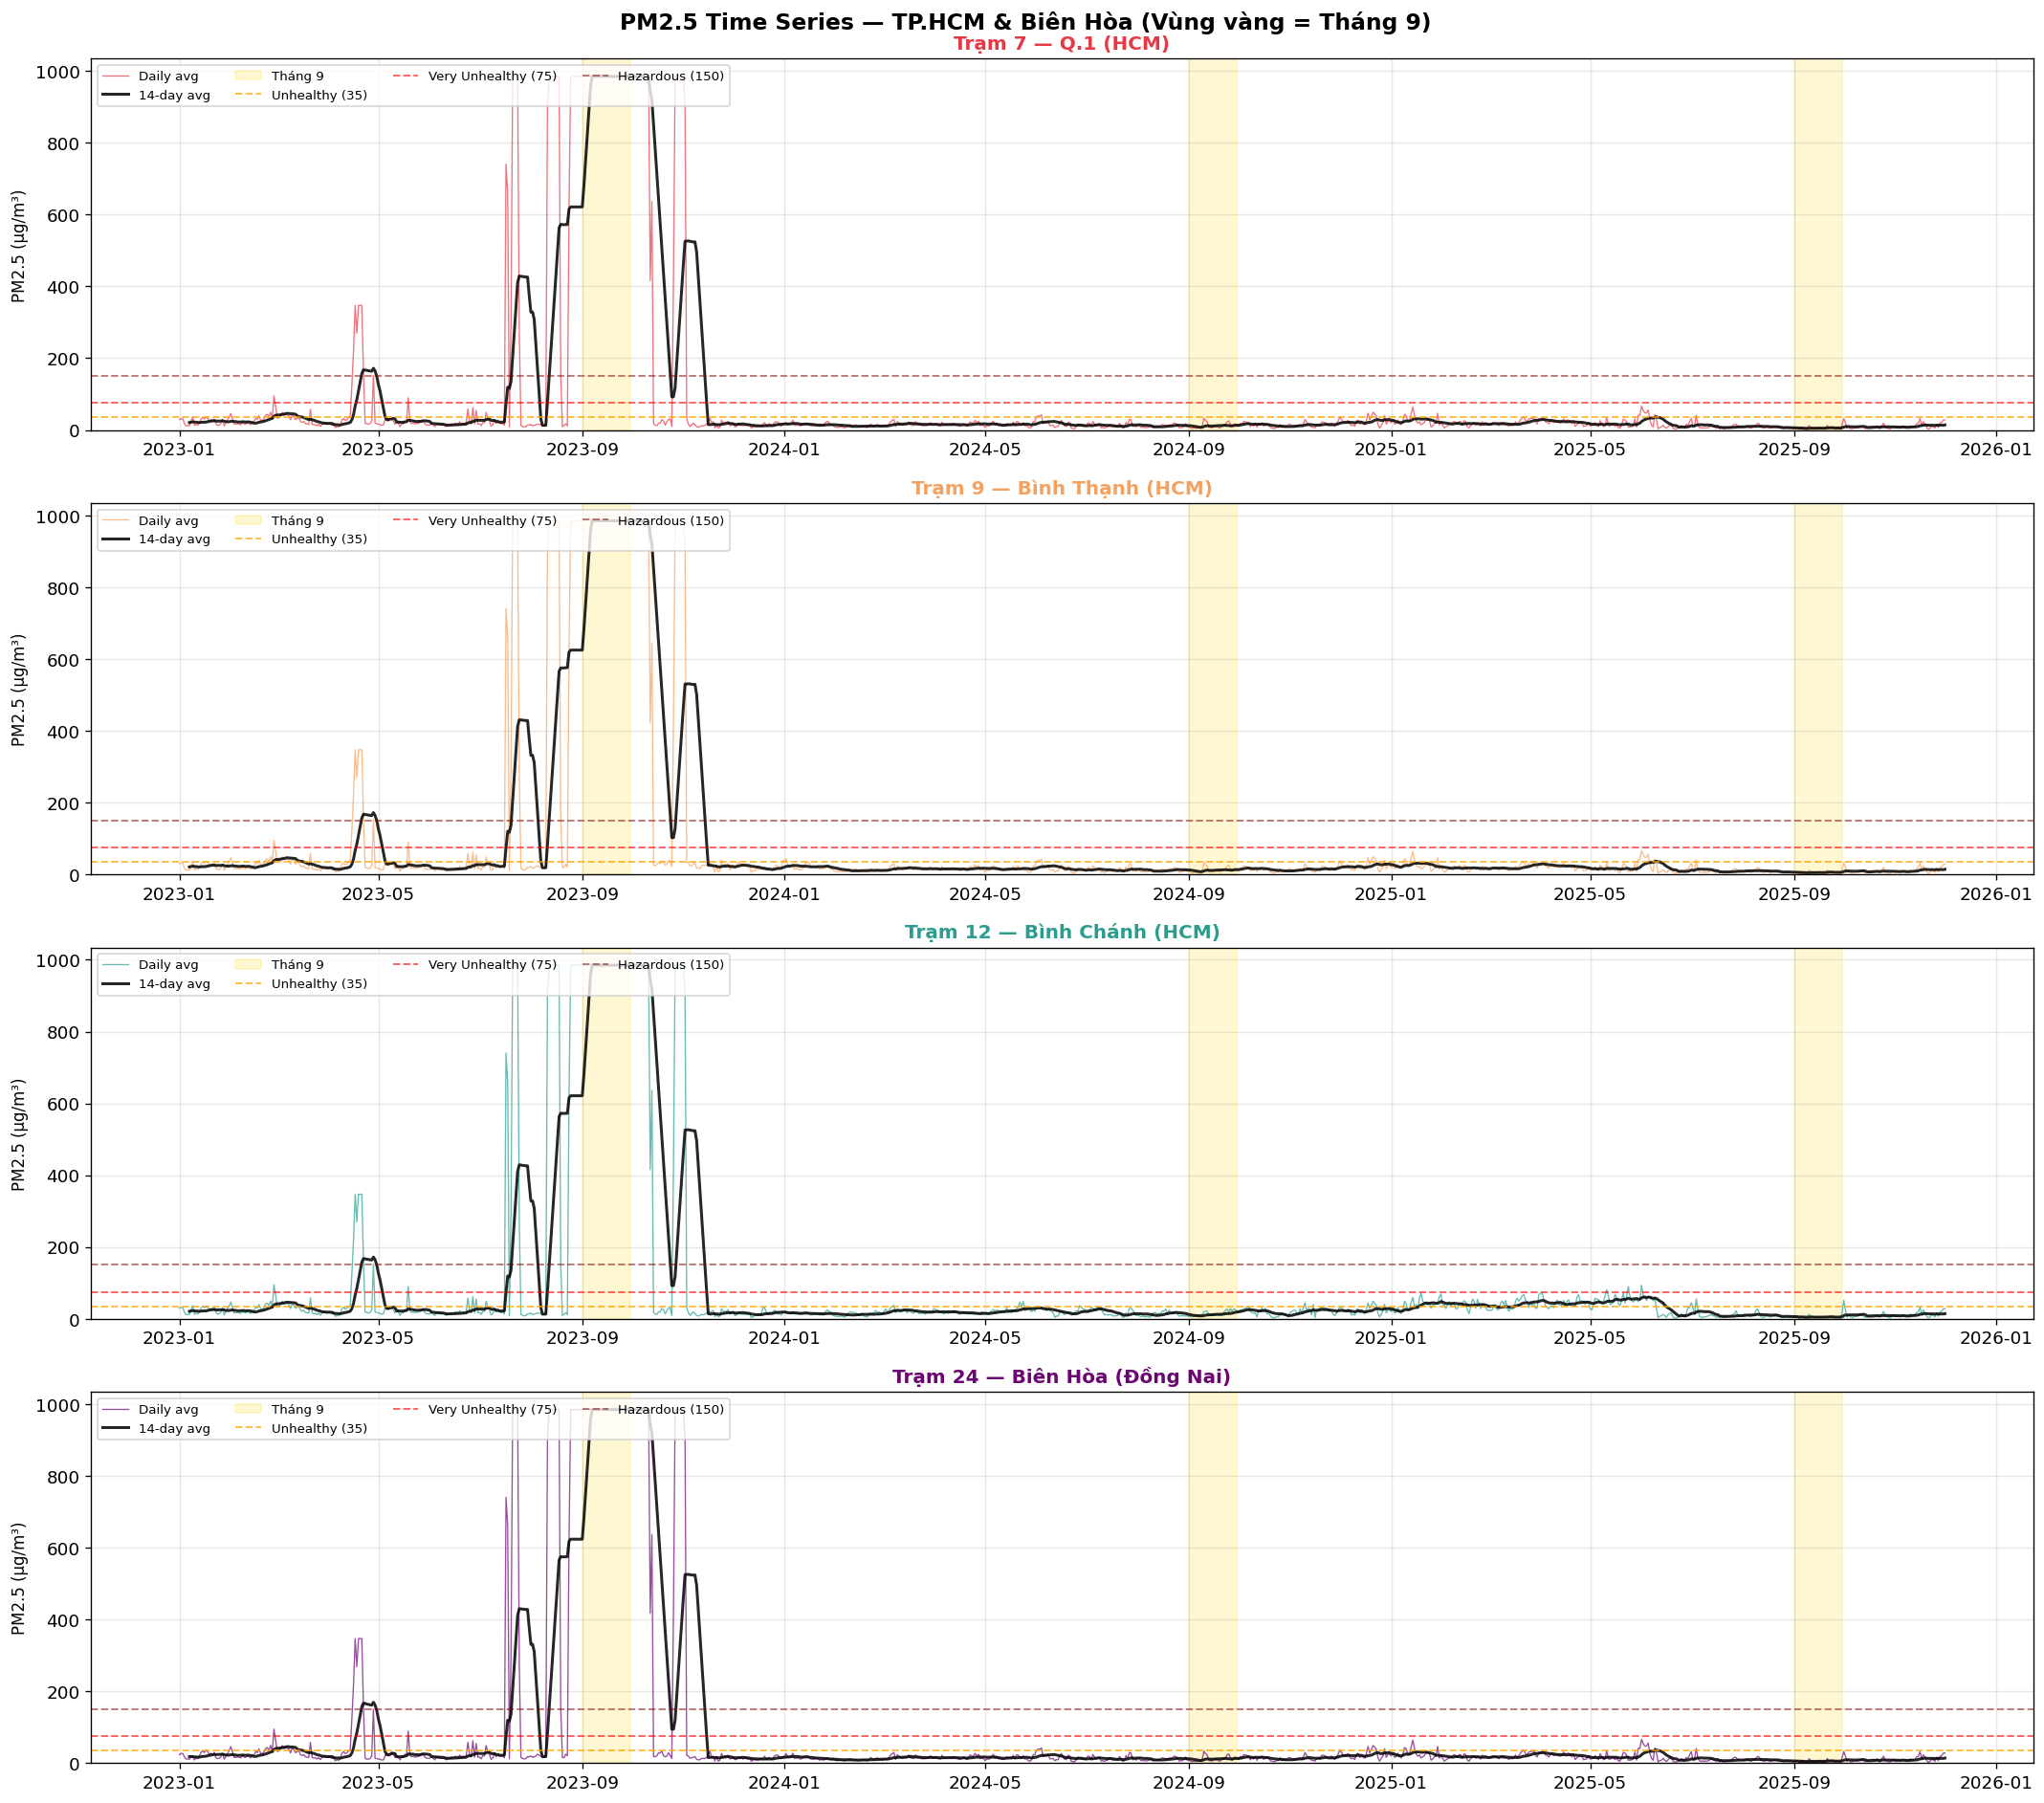

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=False)

for ax, (sid, lbl) in zip(axes, FOCUS_STATIONS.items()):
    df    = focus_dfs[sid]
    daily = df['PM2.5'].resample('D').mean()
    color = COLORS[sid]

    ax.plot(daily, color=color, lw=0.8, alpha=0.7, label='Daily avg')
    ax.plot(daily.rolling(14, min_periods=7).mean(),
            color='black', lw=1.8, alpha=0.85, label='14-day avg')

    # Highlight vùng tháng 9 của từng năm
    for yr in sorted(daily.index.year.unique()):
        try:
            s = pd.Timestamp(f'{yr}-09-01')
            e = pd.Timestamp(f'{yr}-09-30')
            ax.axvspan(s, e, alpha=0.18, color='gold',
                       label='Tháng 9' if yr == daily.index.year.min() else '')
        except Exception:
            pass

    ax.axhline(35,  color='orange', lw=1.2, ls='--', alpha=0.7, label='Unhealthy (35)')
    ax.axhline(75,  color='red',    lw=1.2, ls='--', alpha=0.6, label='Very Unhealthy (75)')
    ax.axhline(150, color='maroon', lw=1.2, ls='--', alpha=0.5, label='Hazardous (150)')
    ax.set_title(f'Trạm {sid} — {lbl}', fontsize=12, fontweight='bold', color=color)
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=10)
    ax.legend(fontsize=8, loc='upper left', ncol=4)
    ax.set_ylim(bottom=0)

fig.suptitle('PM2.5 Time Series — TP.HCM & Biên Hòa (Vùng vàng = Tháng 9)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('deep_pm25_timeseries_sept.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 Outlier Detection — Monthly Boxplot (IQR)

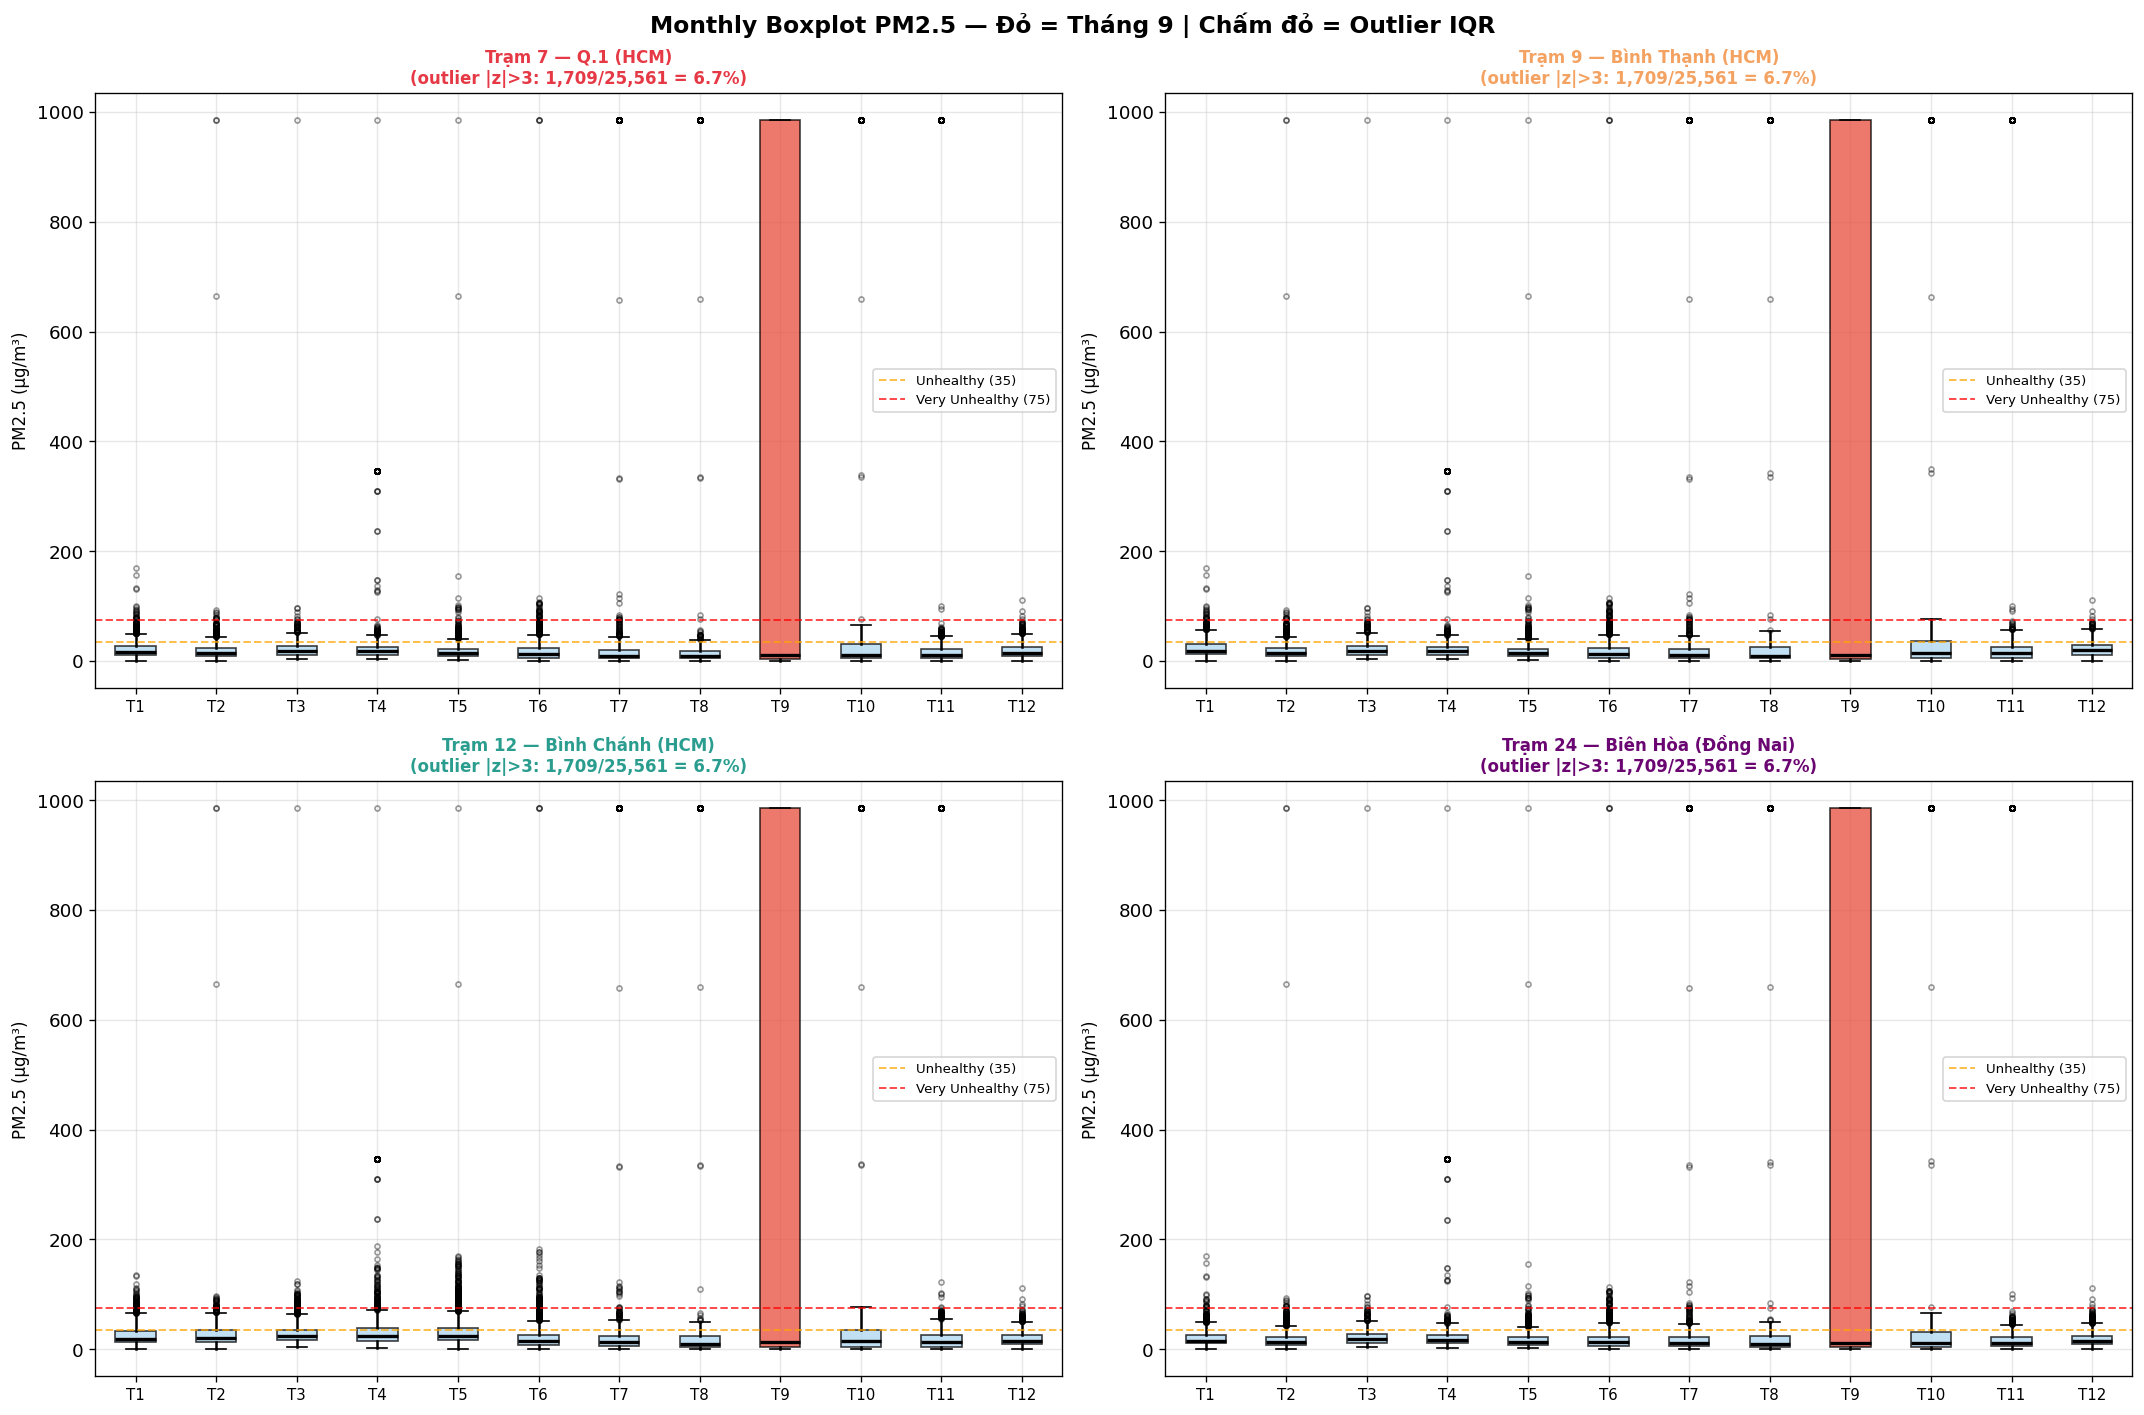

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

for ax, (sid, lbl) in zip(axes, FOCUS_STATIONS.items()):
    df = focus_dfs[sid].copy()
    df['month'] = df.index.month

    pm25_clean = df['PM2.5'].dropna()
    z_scores   = np.abs(stats.zscore(pm25_clean))
    outliers   = pm25_clean[z_scores > 3]

    data_by_month = [df[df['month'] == m]['PM2.5'].dropna().values for m in range(1, 13)]

    bp = ax.boxplot(data_by_month, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='o', color='red', markersize=3, alpha=0.4),
                    whiskerprops=dict(lw=1.5))

    palette = ['#AED6F1'] * 12
    palette[8] = '#E74C3C'  # tháng 9
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)

    ax.axhline(35, color='orange', lw=1.2, ls='--', alpha=0.7, label='Unhealthy (35)')
    ax.axhline(75, color='red',    lw=1.2, ls='--', alpha=0.7, label='Very Unhealthy (75)')
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.set_title(
        f'Trạm {sid} — {lbl}\n'
        f'(outlier |z|>3: {len(outliers):,}/{len(pm25_clean):,} = {len(outliers)/len(pm25_clean)*100:.1f}%)',
        fontsize=10, fontweight='bold', color=COLORS[sid]
    )
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Monthly Boxplot PM2.5 — Đỏ = Tháng 9 | Chấm đỏ = Outlier IQR',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('deep_monthly_boxplot_outlier.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Zoom In tháng 9 — PM2.5 daily từng năm

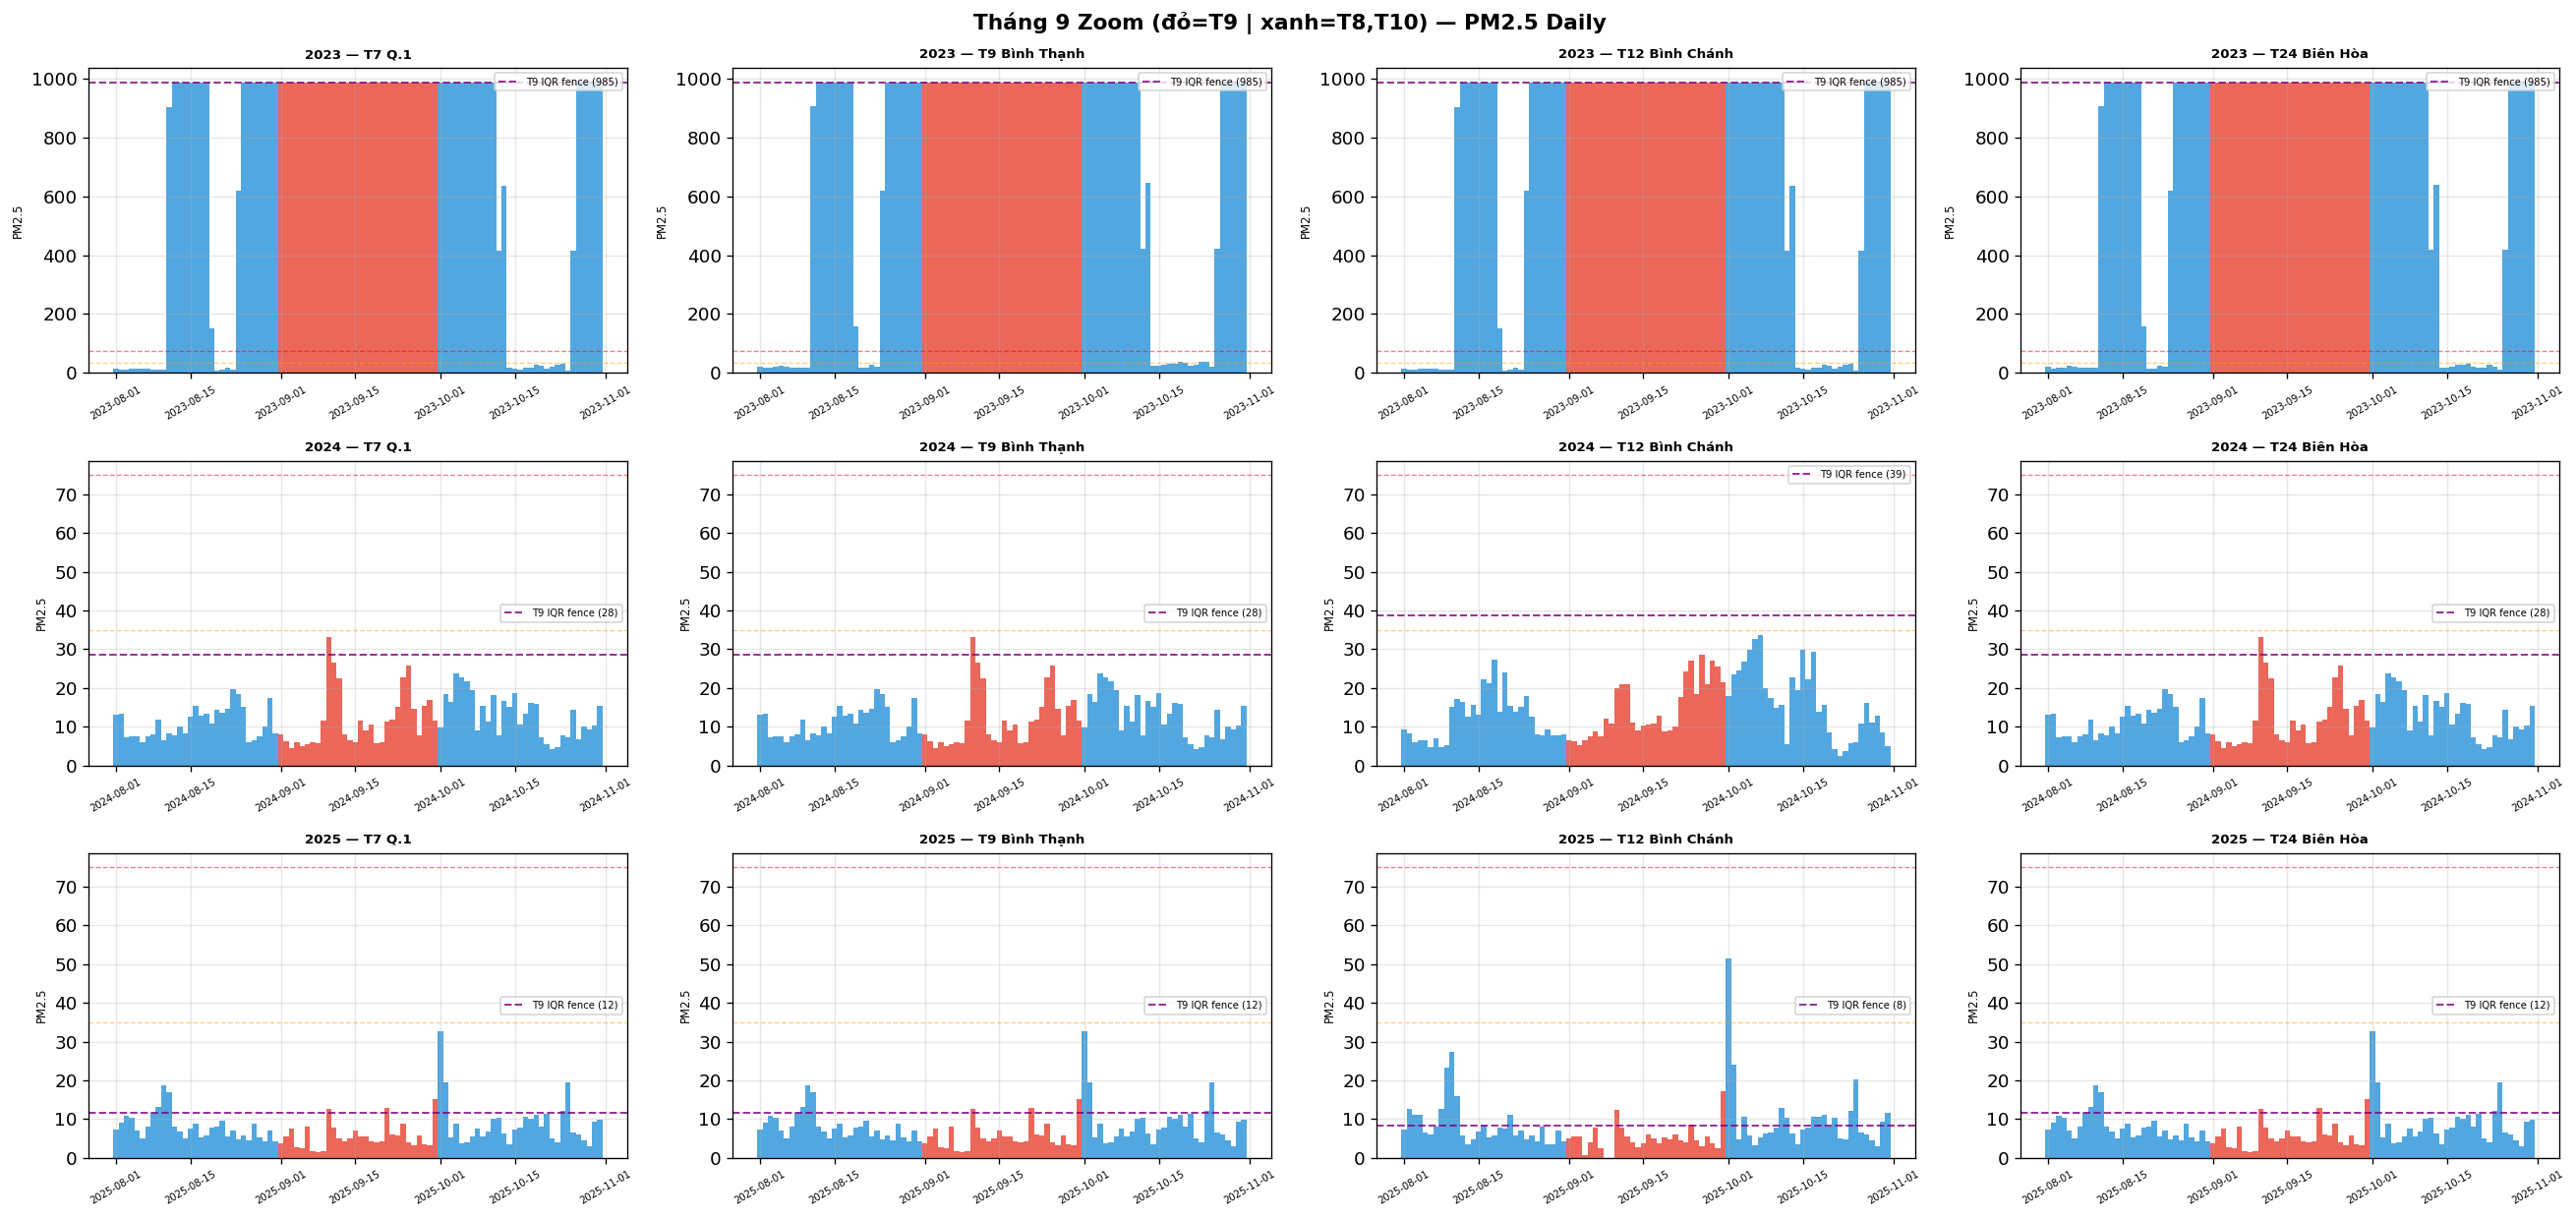

In [21]:
all_years = sorted(focus_dfs[7].index.year.unique())
n_years   = len(all_years)

fig, axes = plt.subplots(n_years, 4, figsize=(22, n_years * 3.5))
if n_years == 1:
    axes = axes.reshape(1, -1)

for row, yr in enumerate(all_years):
    for col, (sid, lbl) in enumerate(FOCUS_STATIONS.items()):
        ax = axes[row][col]
        df = focus_dfs[sid]

        # Lấy tháng 8–10 để có ngữ cảnh
        mask = (df.index.year == yr) & (df.index.month.isin([8, 9, 10]))
        sub  = df.loc[mask, 'PM2.5'].resample('D').mean().dropna()

        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        else:
            bar_colors = ['#E74C3C' if m == 9 else '#3498DB' for m in sub.index.month]
            ax.bar(sub.index, sub.values, color=bar_colors, width=1, alpha=0.85)

            sep = sub[sub.index.month == 9]
            if len(sep) > 3:
                q1, q3 = sep.quantile(0.25), sep.quantile(0.75)
                iqr    = q3 - q1
                ax.axhline(q3 + 1.5 * iqr, color='purple', lw=1.2, ls='--',
                           alpha=0.8, label=f'T9 IQR fence ({q3 + 1.5*iqr:.0f})')
            ax.axhline(75,  color='red',    lw=0.8, ls='--', alpha=0.5)
            ax.axhline(35,  color='orange', lw=0.8, ls='--', alpha=0.5)
            ax.legend(fontsize=6)

        short_lbl = lbl.split('(')[0].strip()
        ax.set_title(f'{yr} — T{sid} {short_lbl}', fontsize=8, fontweight='bold')
        ax.set_ylabel('PM2.5', fontsize=7)
        ax.tick_params(axis='x', rotation=30, labelsize=6)

fig.suptitle('Tháng 9 Zoom (đỏ=T9 | xanh=T8,T10) — PM2.5 Daily',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deep_sept_zoom.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.4 Hourly Pattern — Tháng 9 vs Các tháng còn lại

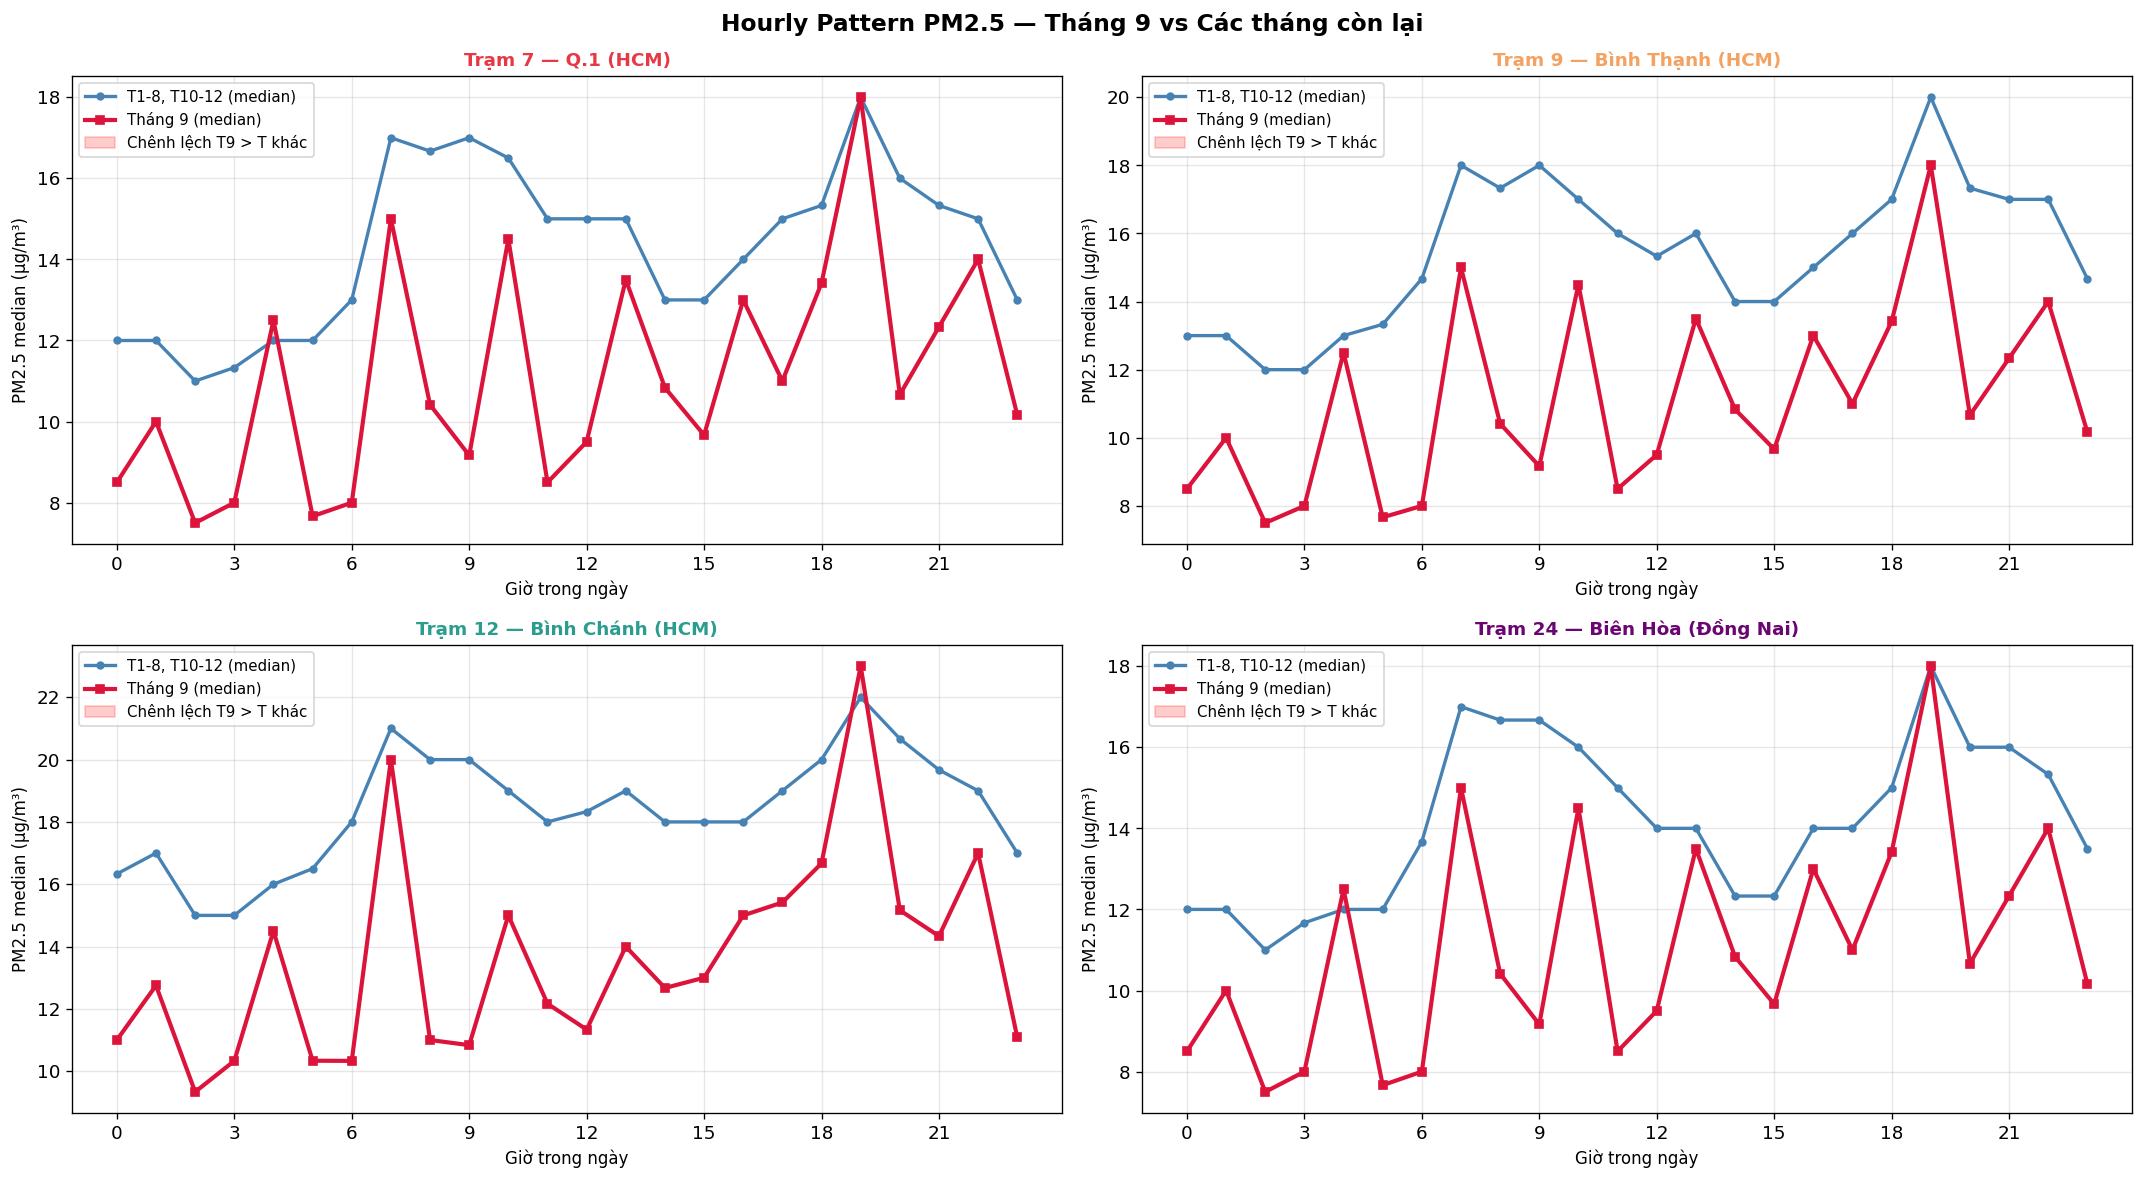

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (sid, lbl) in zip(axes, FOCUS_STATIONS.items()):
    df = focus_dfs[sid].copy()
    df['hour']  = df.index.hour
    df['month'] = df.index.month
    df['is_sep'] = df['month'] == 9

    hourly_sep   = df[df['is_sep']].groupby('hour')['PM2.5'].median()
    hourly_other = df[~df['is_sep']].groupby('hour')['PM2.5'].median()

    ax.plot(hourly_other.index, hourly_other.values,
            color='steelblue', lw=2, marker='o', ms=4, label='T1-8, T10-12 (median)')
    ax.plot(hourly_sep.index, hourly_sep.values,
            color='crimson', lw=2.5, marker='s', ms=5, label='Tháng 9 (median)')

    idx_common = hourly_other.index
    sep_aligned = hourly_sep.reindex(idx_common)
    ax.fill_between(
        idx_common,
        hourly_other.values,
        sep_aligned.values,
        where=(sep_aligned.values > hourly_other.values),
        alpha=0.2, color='red', label='Chênh lệch T9 > T khác'
    )

    ax.set_xlabel('Giờ trong ngày', fontsize=10)
    ax.set_ylabel('PM2.5 median (µg/m³)', fontsize=10)
    ax.set_title(f'Trạm {sid} — {lbl}', fontsize=11, fontweight='bold', color=COLORS[sid])
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=9)

fig.suptitle('Hourly Pattern PM2.5 — Tháng 9 vs Các tháng còn lại',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('deep_hourly_sept_vs_other.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.5 Pollutant Co-behavior — PM2.5 vs các chất khác theo tháng

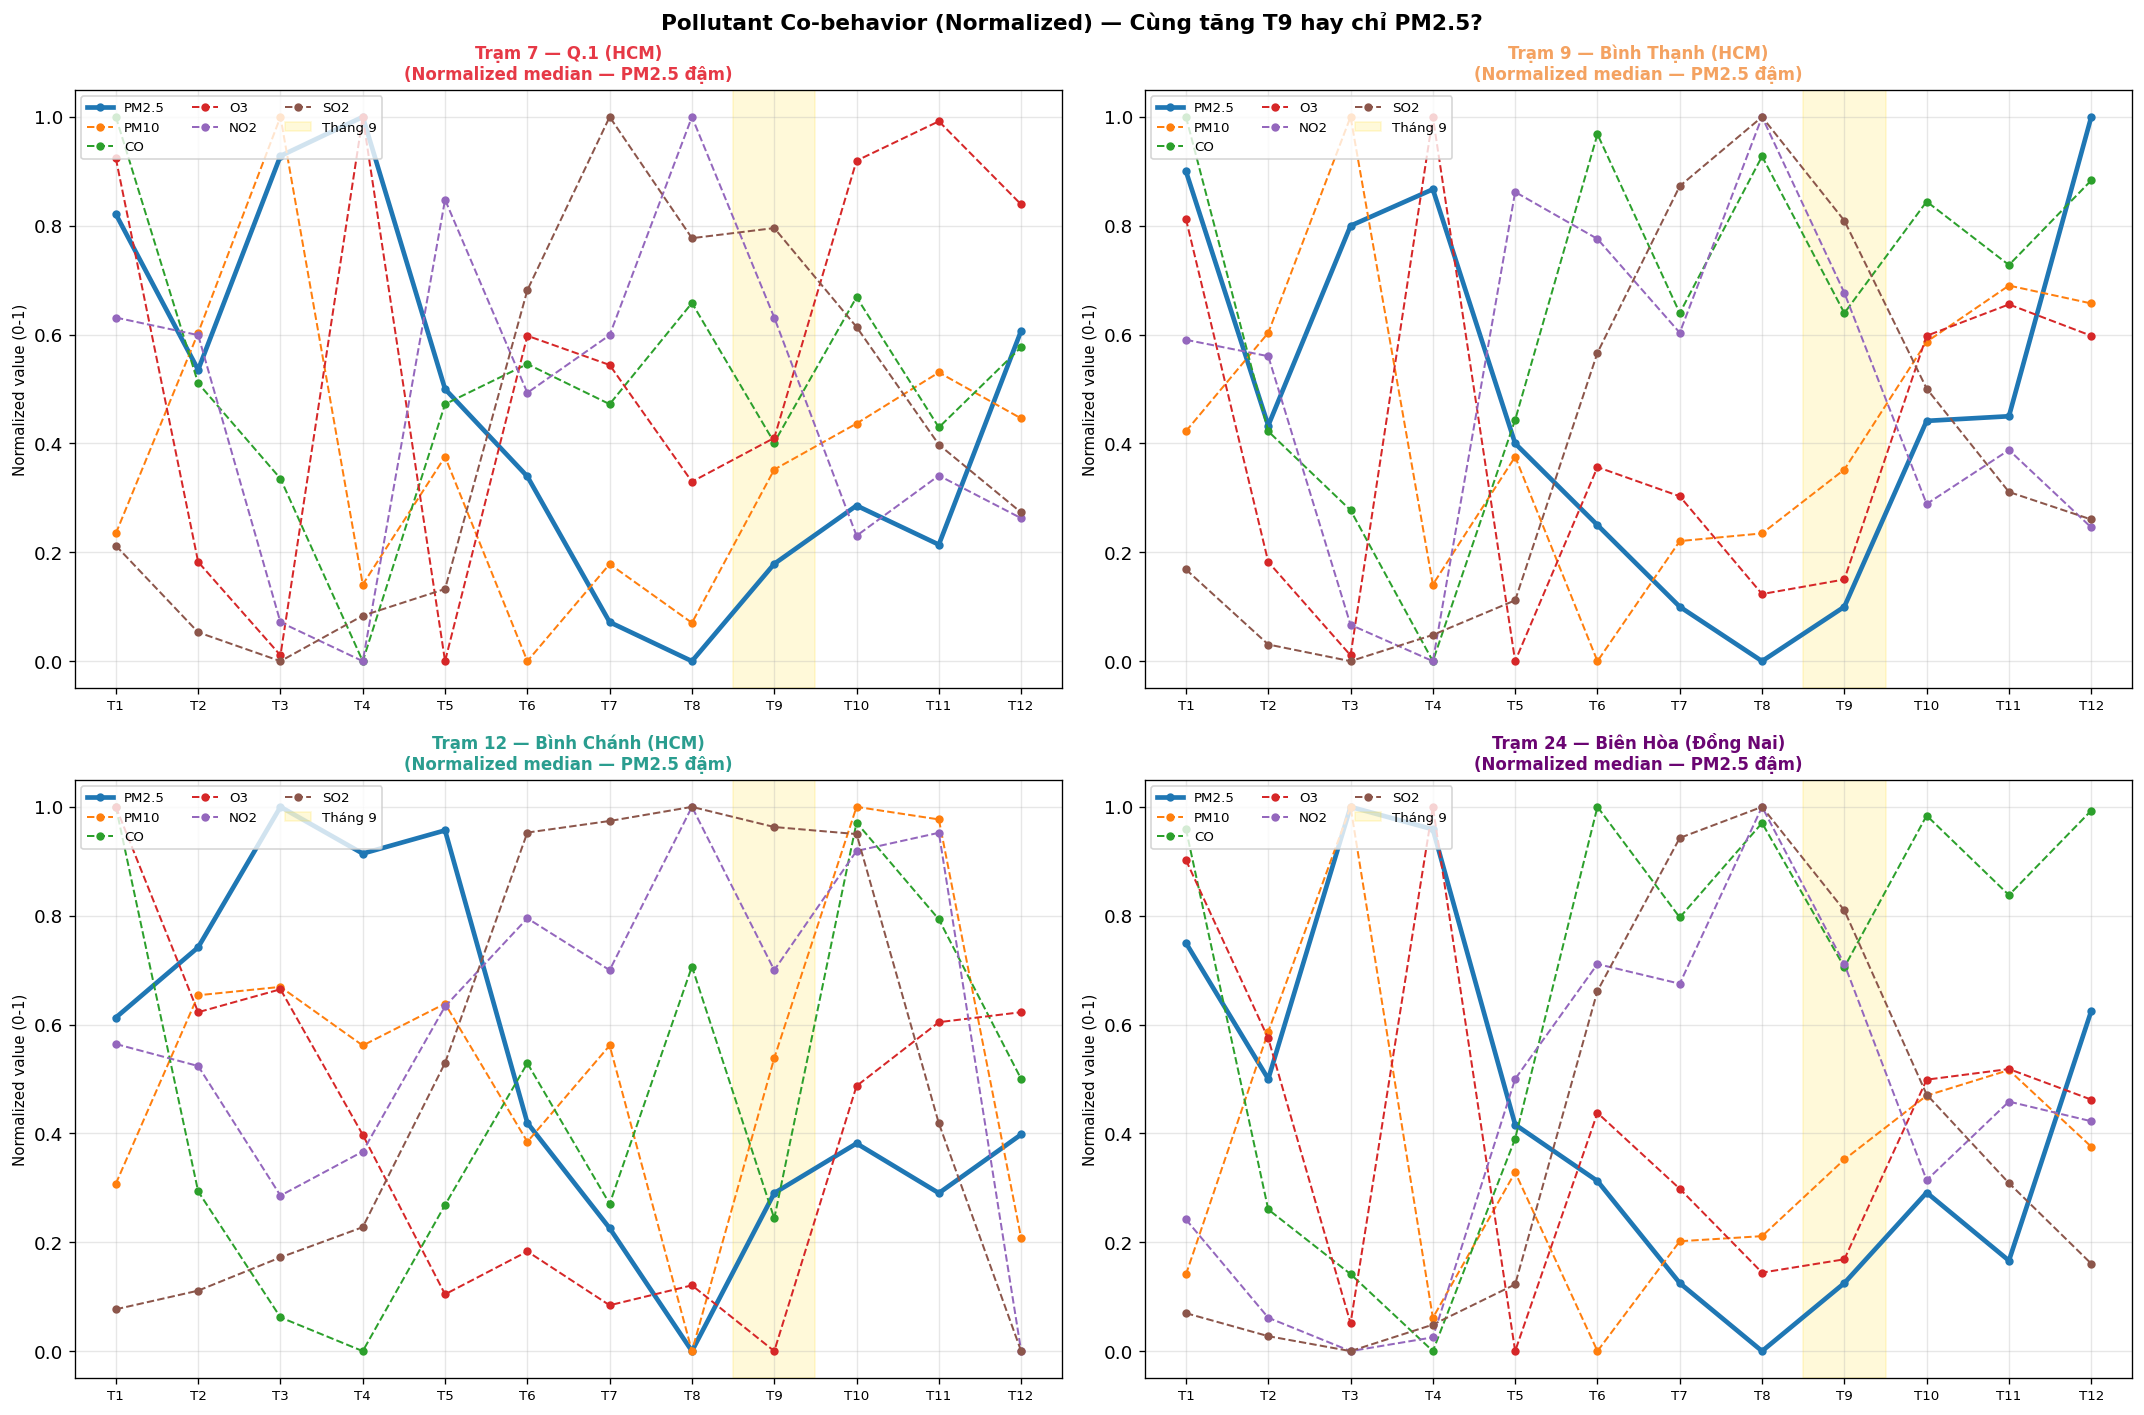


Phân tích kết quả:
  PM2.5 tang T9 nhung CO/NO2/SO2 khong tang  -> Khoi xuyen bien gioi (chay rung SEA)
  Nhieu chat cung tang                        -> Nguon phat thai dia phuong
  Chi 1 tram bat thuong                       -> Nghi cam bien loi


In [23]:
# Nếu PM2.5 tăng T9 nhưng CO/NO2/SO2 KHÔNG tăng → khói xuyên biên giới
# Nếu nhiều chất cùng tăng → nguồn phát thải địa phương
POLL_COLS = ['PM2.5', 'PM10', 'CO', 'O3', 'NO2', 'SO2']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (sid, lbl) in zip(axes, FOCUS_STATIONS.items()):
    df = focus_dfs[sid].copy()
    df['month'] = df.index.month

    records = []
    for m in range(1, 13):
        row = {'month': m}
        for p in POLL_COLS:
            if p in df.columns:
                row[p] = df[df['month'] == m][p].median()
        records.append(row)
    monthly = pd.DataFrame(records).set_index('month')

    # Normalize 0-1 để so sánh cùng trục
    monthly_norm = (monthly - monthly.min()) / (monthly.max() - monthly.min() + 1e-9)

    for i, p in enumerate(POLL_COLS):
        if p in monthly_norm.columns:
            lw_val = 2.8 if p == 'PM2.5' else 1.2
            ls_val = '-'  if p == 'PM2.5' else '--'
            ax.plot(monthly_norm.index, monthly_norm[p],
                    lw=lw_val, ls=ls_val, marker='o', ms=4,
                    label=p, color=plt.cm.tab10(i))

    ax.axvspan(8.5, 9.5, alpha=0.15, color='gold', label='Tháng 9')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['T'+str(i) for i in range(1, 13)], fontsize=8)
    ax.set_title(f'Trạm {sid} — {lbl}\n(Normalized median — PM2.5 đậm)',
                 fontsize=10, fontweight='bold', color=COLORS[sid])
    ax.set_ylabel('Normalized value (0-1)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left', ncol=3)
    ax.set_xlim([0.5, 12.5])

fig.suptitle('Pollutant Co-behavior (Normalized) — Cùng tăng T9 hay chỉ PM2.5?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deep_pollutant_cobehavior.png', dpi=120, bbox_inches='tight')
plt.show()
print()
print('Phân tích kết quả:')
print('  PM2.5 tang T9 nhung CO/NO2/SO2 khong tang  -> Khoi xuyen bien gioi (chay rung SEA)')
print('  Nhieu chat cung tang                        -> Nguon phat thai dia phuong')
print('  Chi 1 tram bat thuong                       -> Nghi cam bien loi')

### 4.6 Statistical Summary — Tháng 9 vs Toàn năm

In [25]:
print('=' * 85)
print('STATISTICAL SUMMARY: PM2.5 — Tháng 9 vs Toàn năm')
print('=' * 85)

summary_rows = []
for sid, lbl in FOCUS_STATIONS.items():
    df = focus_dfs[sid].copy()
    df['month'] = df.index.month
    pm_all  = df['PM2.5'].dropna()
    pm_sep  = df[df['month'] == 9]['PM2.5'].dropna()
    pm_rest = df[df['month'] != 9]['PM2.5'].dropna()

    q1, q3  = pm_all.quantile(0.25), pm_all.quantile(0.75)
    iqr     = q3 - q1
    fence   = q3 + 1.5 * iqr

    summary_rows.append({
        'Station'       : f'T{sid} {lbl}',
        'Mean (all)'    : round(pm_all.mean(), 1),
        'Mean (T9)'     : round(pm_sep.mean(), 1),
        'Mean (T khac)' : round(pm_rest.mean(), 1),
        'Median (T9)'   : round(pm_sep.median(), 1),
        'Max (T9)'      : round(pm_sep.max(), 1),
        'IQR fence'     : round(fence, 1),
        'Outlier% T9'   : f"{(pm_sep > fence).mean()*100:.1f}%",
        'Outlier% rest' : f"{(pm_rest > fence).mean()*100:.1f}%",
    })

summary_df = pd.DataFrame(summary_rows).set_index('Station')
display(summary_df)
print()
print('Outlier% T9 >> Outlier% rest -> Thang 9 co van de that su, can dieu tra nguon')

STATISTICAL SUMMARY: PM2.5 — Tháng 9 vs Toàn năm


,Mean (all),Mean (T9),Mean (T khac),Median (T9),Max (T9),IQR fence,Outlier% T9,Outlier% rest
Station,,,,,,,,
T7 Q.1 (HCM),83.3,334.2,60.2,11.0,985.0,50.5,33.8%,7.3%
T9 Bình Thạnh (HCM),84.2,334.2,61.1,11.0,985.0,55.5,33.6%,6.6%
T12 Bình Chánh (HCM),87.9,334.8,65.1,14.0,985.0,67.7,33.4%,7.7%
T24 Biên Hòa (Đồng Nai),83.3,334.2,60.1,11.0,985.0,51.0,33.8%,7.2%



Outlier% T9 >> Outlier% rest -> Thang 9 co van de that su, can dieu tra nguon


### 4.7 Raw Data Audit — Top spike trong tháng 9

In [26]:
print('TOP 15 GIA TRI PM2.5 CAO NHAT TRONG THANG 9 — MỖI TRẠM')
print('=' * 85)

for sid, lbl in FOCUS_STATIONS.items():
    df = focus_dfs[sid].copy()
    sep_data = df[df.index.month == 9]
    cols_show = [c for c in ['PM2.5','PM10','CO','NO2','SO2','Wind_Speed','Humidity','Precipitation'] if c in sep_data.columns]
    top15 = sep_data[cols_show].nlargest(15, 'PM2.5')
    print(f'\nTram {sid} - {lbl}  (n_sep={len(sep_data)}, % > 75: {(sep_data["PM2.5"]>75).mean()*100:.1f}%)')
    display(top15.round(2))

TOP 15 GIA TRI PM2.5 CAO NHAT TRONG THANG 9 — MỖI TRẠM

Tram 7 - Q.1 (HCM)  (n_sep=2160, % > 75: 33.5%)


,PM2.5,PM10,CO,NO2,SO2,Wind_Speed,Humidity,Precipitation
datetime,,,,,,,,
2023-09-01 00:00:00,985.0,1231.3,58.0,5.3,14.7,1.92,93,0.3
2023-09-01 01:00:00,985.0,1231.3,54.9,5.0,13.0,1.91,95,0.2
2023-09-01 02:00:00,985.0,1231.3,53.9,5.3,15.0,2.48,95,0.1
2023-09-01 03:00:00,985.0,1231.3,52.9,5.7,17.0,3.26,94,0.0
2023-09-01 04:00:00,985.0,1231.3,51.9,6.0,19.0,3.68,95,0.0
2023-09-01 05:00:00,985.0,1231.3,51.4,5.7,18.3,3.69,96,0.1
2023-09-01 06:00:00,985.0,1231.3,50.8,5.3,17.7,3.77,95,0.2
2023-09-01 07:00:00,985.0,1231.3,50.2,5.0,17.0,3.83,91,0.7
2023-09-01 08:00:00,985.0,1231.3,50.8,4.7,16.7,4.30,88,0.2



Tram 9 - Bình Thạnh (HCM)  (n_sep=2160, % > 75: 33.5%)


,PM2.5,PM10,CO,NO2,SO2,Wind_Speed,Humidity,Precipitation
datetime,,,,,,,,
2023-09-01 00:00:00,985.0,1231.3,115.6,24.0,84.7,1.92,93,0.3
2023-09-01 01:00:00,985.0,1231.3,102.7,22.0,78.0,1.91,95,0.2
2023-09-01 02:00:00,985.0,1231.3,97.3,21.3,74.7,2.48,95,0.1
2023-09-01 03:00:00,985.0,1231.3,91.8,20.7,71.3,3.26,94,0.0
2023-09-01 04:00:00,985.0,1231.3,86.4,20.0,68.0,3.68,95,0.0
2023-09-01 05:00:00,985.0,1231.3,82.1,19.3,69.7,3.69,96,0.1
2023-09-01 06:00:00,985.0,1231.3,77.8,18.7,71.3,3.77,95,0.2
2023-09-01 07:00:00,985.0,1231.3,73.5,18.0,73.0,3.83,91,0.7
2023-09-01 08:00:00,985.0,1231.3,69.4,16.0,66.7,4.30,88,0.2



Tram 12 - Bình Chánh (HCM)  (n_sep=2160, % > 75: 33.3%)


,PM2.5,PM10,CO,NO2,SO2,Wind_Speed,Humidity,Precipitation
datetime,,,,,,,,
2023-09-01 00:00:00,985.0,1231.3,58.0,5.3,14.7,1.63,95,0.1
2023-09-01 01:00:00,985.0,1231.3,54.9,5.0,13.0,2.48,96,0.1
2023-09-01 02:00:00,985.0,1231.3,53.9,5.3,15.0,2.83,95,0.1
2023-09-01 03:00:00,985.0,1231.3,52.9,5.7,17.0,3.33,96,0.0
2023-09-01 04:00:00,985.0,1231.3,51.9,6.0,19.0,3.82,96,0.0
2023-09-01 05:00:00,985.0,1231.3,51.4,5.7,18.3,3.55,97,0.1
2023-09-01 06:00:00,985.0,1231.3,50.8,5.3,17.7,3.94,95,0.1
2023-09-01 07:00:00,985.0,1231.3,50.2,5.0,17.0,3.96,93,0.0
2023-09-01 08:00:00,985.0,1231.3,50.8,4.7,16.7,4.22,87,0.1



Tram 24 - Biên Hòa (Đồng Nai)  (n_sep=2160, % > 75: 33.5%)


,PM2.5,PM10,CO,NO2,SO2,Wind_Speed,Humidity,Precipitation
datetime,,,,,,,,
2023-09-01 00:00:00,985.0,1231.3,96.5,13.0,47.3,1.70,96,0.9
2023-09-01 01:00:00,985.0,1231.3,88.1,13.0,49.0,1.17,95,0.3
2023-09-01 02:00:00,985.0,1231.3,84.8,13.0,47.3,1.41,96,0.1
2023-09-01 03:00:00,985.0,1231.3,81.5,13.0,45.7,2.83,96,0.0
2023-09-01 04:00:00,985.0,1231.3,78.2,13.0,44.0,3.25,96,0.0
2023-09-01 05:00:00,985.0,1231.3,76.3,12.7,45.3,3.08,97,0.1
2023-09-01 06:00:00,985.0,1231.3,74.3,12.3,46.7,3.77,95,0.2
2023-09-01 07:00:00,985.0,1231.3,72.4,12.0,48.0,2.47,92,0.8
2023-09-01 08:00:00,985.0,1231.3,66.1,10.7,44.7,2.91,89,0.7
